# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

email = '202637883@alu.comillas.edu'

if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

import itertools

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# Cargar el dataset Iris
dataset = datasets.load_iris()

# Crear un DataFrame para mejor visualización
df = pd.DataFrame(
    data=dataset.data,
    columns=dataset.feature_names
)
df['species'] = dataset.target
df['species_name'] = df['species'].map({
    0: 'Setosa',
    1: 'Versicolor', 
    2: 'Virginica'
})

print("=" * 70)
print("🌸 DATASET IRIS - INFORMACIÓN GENERAL")
print("=" * 70)
print(f"📦 Número total de muestras: {len(df)}") 
print(f"📊 Características (features): {len(dataset.feature_names)}")
print(f"🎯 Clases: {len(dataset.target_names)}")
print(f"\n🌺 Distribución de clases:")
print(df['species_name'].value_counts().to_string())

print(f"\n📏 Características del dataset:")
for i, feature in enumerate(dataset.feature_names, 1):
    print(f"   {i}. {feature}")

print("\n" + "=" * 70)
print("📊 PRIMERAS 5 MUESTRAS:")
print("=" * 70)
print(df.head().to_string())

print("\n" + "=" * 70)
print("📈 ESTADÍSTICAS DESCRIPTIVAS:")
print("=" * 70)
print(df.describe().to_string())

🌸 DATASET IRIS - INFORMACIÓN GENERAL
📦 Número total de muestras: 150
📊 Características (features): 4
🎯 Clases: 3

🌺 Distribución de clases:
species_name
Setosa        50
Versicolor    50
Virginica     50

📏 Características del dataset:
   1. sepal length (cm)
   2. sepal width (cm)
   3. petal length (cm)
   4. petal width (cm)

📊 PRIMERAS 5 MUESTRAS:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  species species_name
0                5.1               3.5                1.4               0.2        0       Setosa
1                4.9               3.0                1.4               0.2        0       Setosa
2                4.7               3.2                1.3               0.2        0       Setosa
3                4.6               3.1                1.5               0.2        0       Setosa
4                5.0               3.6                1.4               0.2        0       Setosa

📈 ESTADÍSTICAS DESCRIPTIVAS:
       sepal length (cm)  se

### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

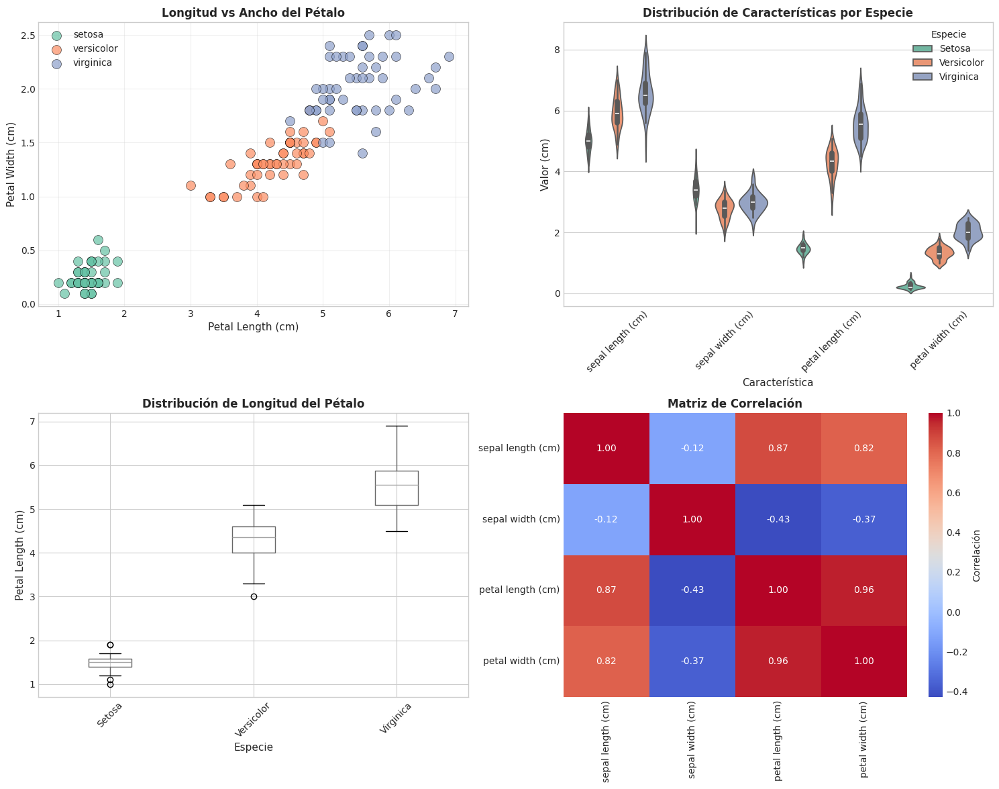

✅ Visualizaciones generadas

🔍 Observaciones clave:
   - Las características del pétalo separan mejor las especies
   - Setosa es claramente separable de las otras dos
   - Versicolor y Virginica tienen mayor solapamiento


In [0]:
# Crear visualizaciones exploratorias
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🌸 Análisis Exploratorio del Dataset Iris', fontsize=16, fontweight='bold')

# Gráfico 1: Pairplot de características más importantes
ax1 = plt.subplot(2, 2, 1)
for species_id, species_name in enumerate(dataset.target_names):
    mask = df['species'] == species_id
    ax1.scatter(
        df[mask]['petal length (cm)'],
        df[mask]['petal width (cm)'],
        label=species_name,
        alpha=0.7,
        s=100,
        edgecolors='black',
        linewidth=0.5
    )
ax1.set_xlabel('Petal Length (cm)', fontsize=11)
ax1.set_ylabel('Petal Width (cm)', fontsize=11)
ax1.set_title('Longitud vs Ancho del Pétalo', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Distribución de características por especie
ax2 = plt.subplot(2, 2, 2)
df_melted = df[['sepal length (cm)', 'sepal width (cm)', 
                'petal length (cm)', 'petal width (cm)', 'species_name']].melt(
    id_vars='species_name',
    var_name='feature',
    value_name='value'
)
sns.violinplot(data=df_melted, x='feature', y='value', hue='species_name', ax=ax2)
ax2.set_xlabel('Característica', fontsize=11)
ax2.set_ylabel('Valor (cm)', fontsize=11)
ax2.set_title('Distribución de Características por Especie', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Especie')

# Gráfico 3: Boxplot de longitud del pétalo
ax3 = plt.subplot(2, 2, 3)
df.boxplot(column='petal length (cm)', by='species_name', ax=ax3)
ax3.set_xlabel('Especie', fontsize=11)
ax3.set_ylabel('Petal Length (cm)', fontsize=11)
ax3.set_title('Distribución de Longitud del Pétalo', fontweight='bold')
plt.sca(ax3)
plt.xticks(rotation=45)
ax3.figure.suptitle('')

# Gráfico 4: Correlación entre características
ax4 = plt.subplot(2, 2, 4)
correlation = df[dataset.feature_names].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=ax4,
            cbar_kws={'label': 'Correlación'})
ax4.set_title('Matriz de Correlación', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones generadas")
print("\n🔍 Observaciones clave:")
print("   - Las características del pétalo separan mejor las especies")
print("   - Setosa es claramente separable de las otras dos")
print("   - Versicolor y Virginica tienen mayor solapamiento")

## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# Separar características (X) y etiquetas (y)
X = dataset.data
y = dataset.target

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,      # 25% para prueba
    random_state=42,     # Reproducibilidad
    stratify=y           # Mantener proporción de clases
)

print("=" * 60)
print("🔀 DIVISIÓN DEL DATASET")
print("=" * 60)
print(f"📊 Total de muestras: {len(X)}")
print(f"\n📚 Conjunto de Entrenamiento:")
print(f"   - Muestras: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Shape: {X_train.shape}")
print(f"   - Distribución de clases:")
unique, counts = np.unique(y_train, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"     • {dataset.target_names[class_id]}: {count} muestras")

print(f"\n🧪 Conjunto de Prueba:")
print(f"   - Muestras: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Shape: {X_test.shape}")
print(f"   - Distribución de clases:")
unique, counts = np.unique(y_test, return_counts=True)
for class_id, count in zip(unique, counts):
    print(f"     • {dataset.target_names[class_id]}: {count} muestras")

print("=" * 60)
print("✅ Datos preparados para entrenamiento")

🔀 DIVISIÓN DEL DATASET
📊 Total de muestras: 150

📚 Conjunto de Entrenamiento:
   - Muestras: 112 (74.7%)
   - Shape: (112, 4)
   - Distribución de clases:
     • setosa: 38 muestras
     • versicolor: 37 muestras
     • virginica: 37 muestras

🧪 Conjunto de Prueba:
   - Muestras: 38 (25.3%)
   - Shape: (38, 4)
   - Distribución de clases:
     • setosa: 12 muestras
     • versicolor: 13 muestras
     • virginica: 13 muestras
✅ Datos preparados para entrenamiento


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/09/28 09:07:33 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


Se van a probar 48 combinaciones


2026/09/28 09:07:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 2
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-cf3f3f8284bd429e962539be75fa3efd?o=7474660565481428
2026/09/28 09:07:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:07:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-724e66ae57924ebf8d632fd1bdc3d17b?o=7474660565481428
2026/09/28 09:07:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:07:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e841f0a075454b5999f1450abffc8110?o=7474660565481428
2026/09/28 09:07:48 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


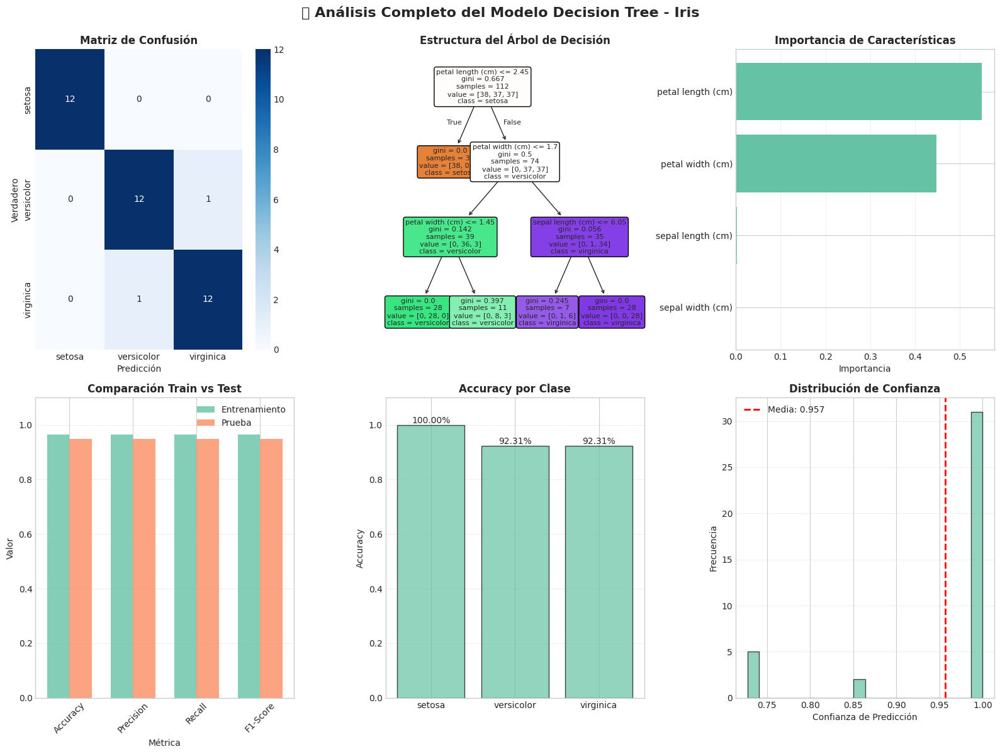

2026/09/28 09:08:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: c74847d47d134121b8395c053afddd90
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 2, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:08:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 2
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-987a85c2f3bb4d6cada6ea74d0c7d0cf?o=7474660565481428
2026/09/28 09:08:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:08:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-4233bb4dab4e4f28ad64b30faf84d42f?o=7474660565481428
2026/09/28 09:08:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-f4460be7821f49abaf00d96cc78b9984?o=7474660565481428
2026/09/28 09:08:23 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


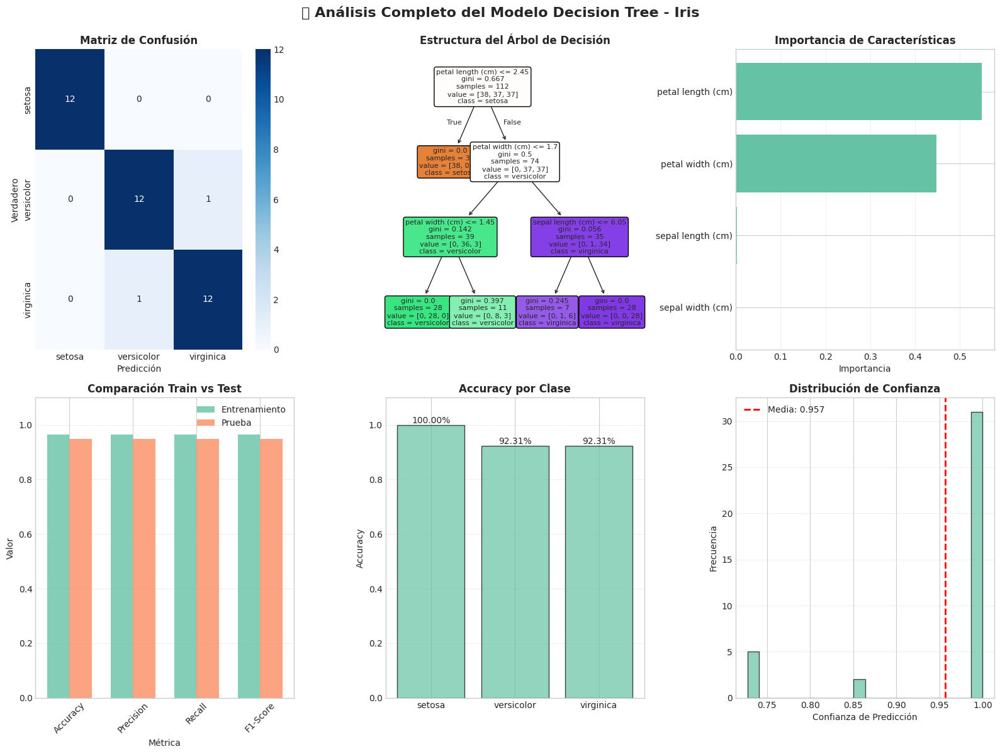

2026/09/28 09:08:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: e2280c6b5b8d4771a0dee14e8830e95a
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 2, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:08:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 2
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-99408a9939eb40e6911a4ec82ff610d5?o=7474660565481428
2026/09/28 09:08:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:08:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-3108e270dddd45b88e01131e16c0651c?o=7474660565481428
2026/09/28 09:08:53 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:08:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-7727faf1066442119b13006e87b1b42c?o=7474660565481428
2026/09/28 09:08:59 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


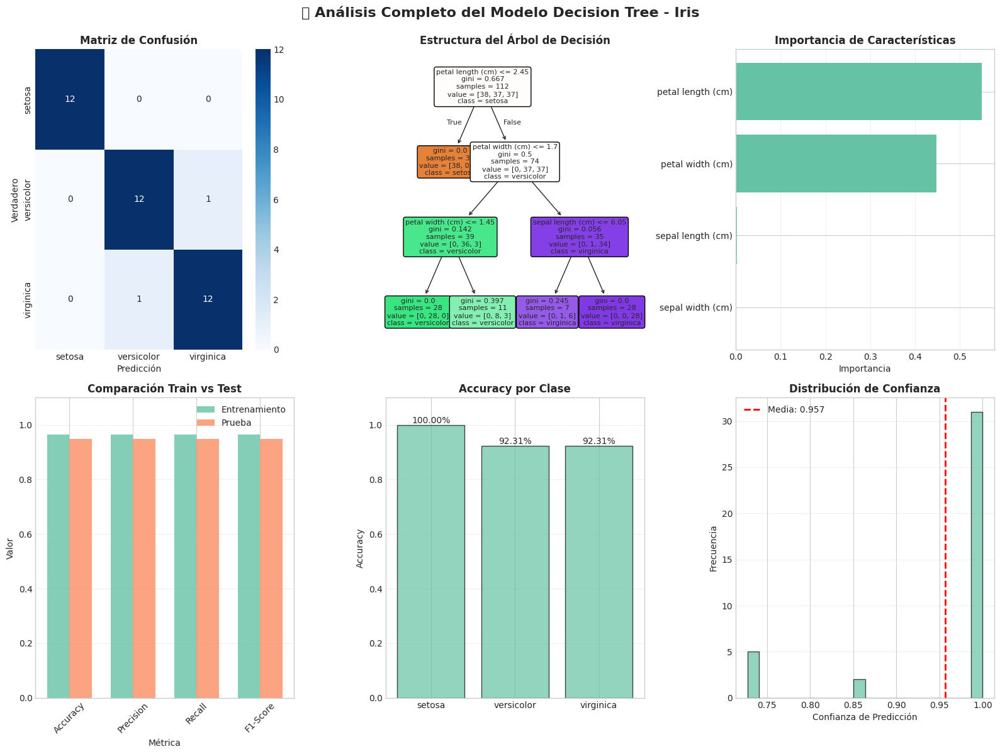

2026/09/28 09:09:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 371f5bca9bb9420dad274f2f56ee9616
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 2, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:09:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 3
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e4bd21527d774eabab9df34457edcdae?o=7474660565481428
2026/09/28 09:09:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:09:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-625d8035cf48498eb2fc44b1d513db2f?o=7474660565481428
2026/09/28 09:09:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-572d25886cac45ff9bee57d76dab43f9?o=7474660565481428
2026/09/28 09:09:35 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


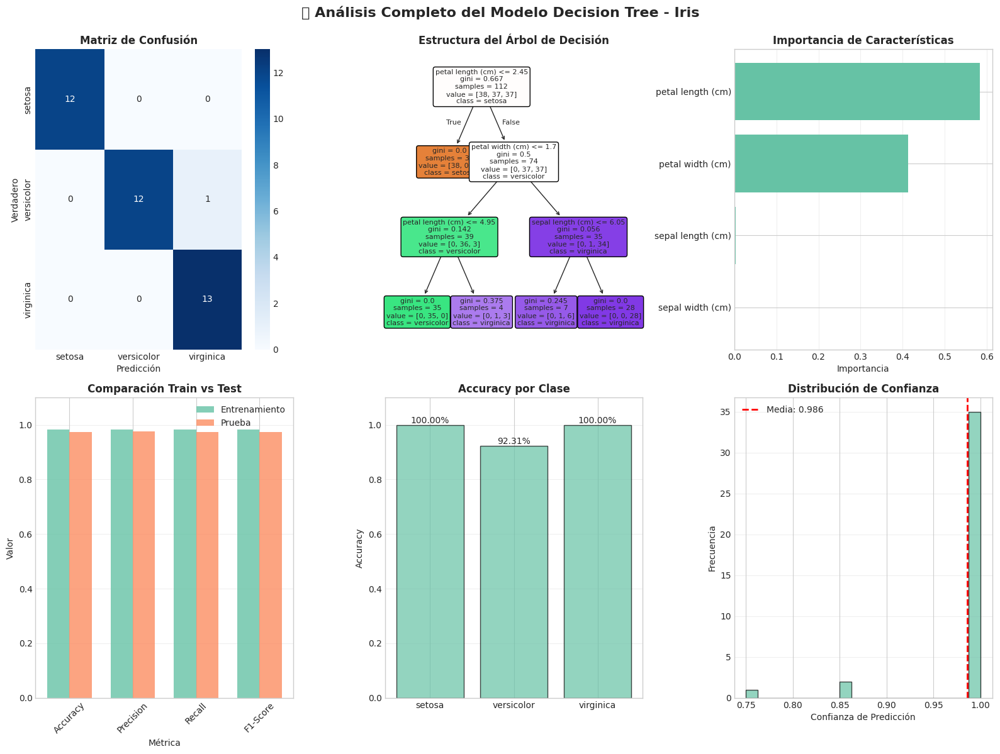

2026/09/28 09:09:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 20b4f0704d9742f695a5a240d2ba23c2
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:09:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:09:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 3
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-479d062b72ac4e7a9eb6f84cb7676301?o=7474660565481428
2026/09/28 09:10:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:10:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-16d1334ec867456686ddc5de48dd0d0f?o=7474660565481428
2026/09/28 09:10:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-bdb4b6e1959d4b41b997f038c6de4d11?o=7474660565481428
2026/09/28 09:10:12 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


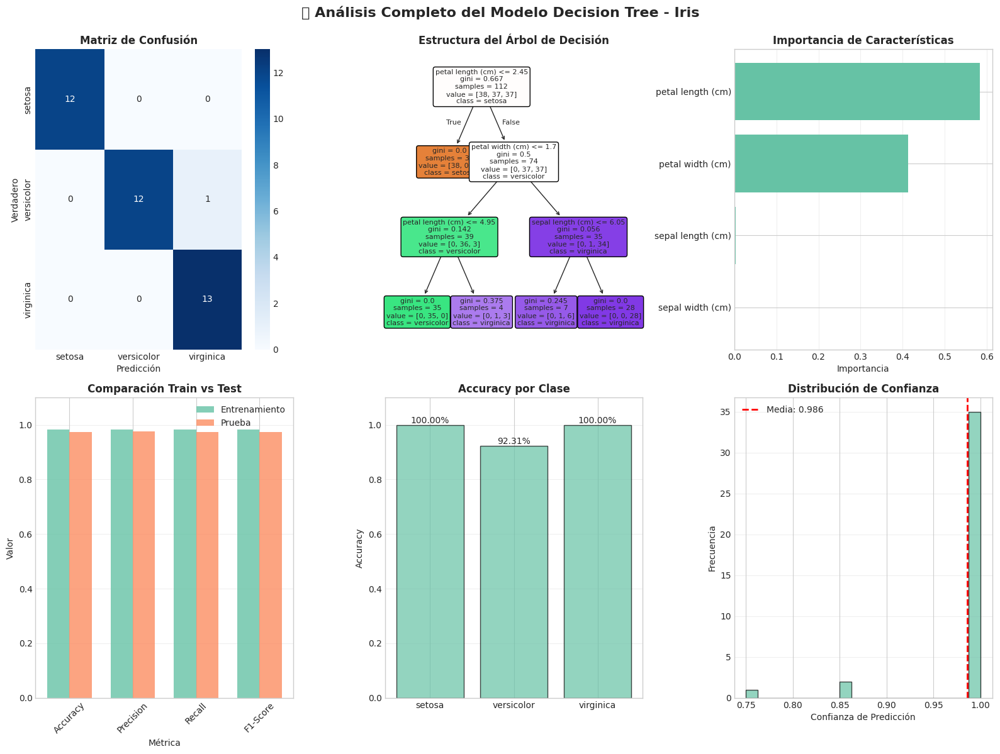

2026/09/28 09:10:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 3138c15f17ec4daca29480b90415896c
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:10:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 3
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5c8999c6c50a47278d80651e00e03bfc?o=7474660565481428
2026/09/28 09:10:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:10:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9af7ce40539641249eab2c966c1c1ce6?o=7474660565481428
2026/09/28 09:10:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:10:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-38a48481896b41b6b5309bc2a8c87e63?o=7474660565481428
2026/09/28 09:10:48 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


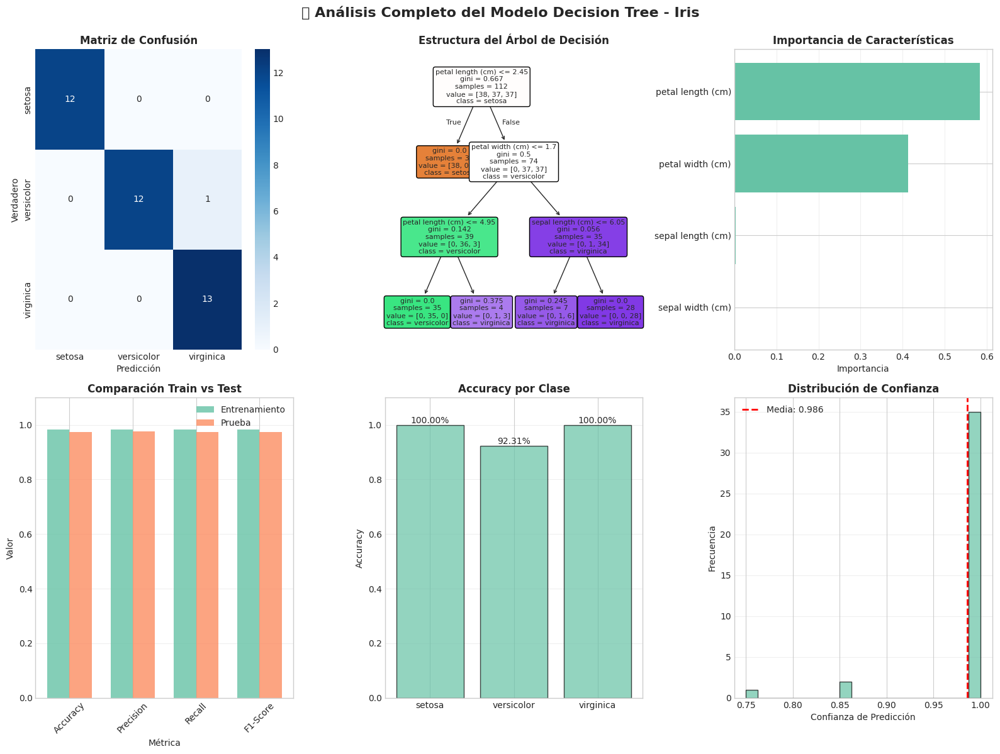

2026/09/28 09:11:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 03f8d148efa94545aef6c1344b381680
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:11:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:09 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 4
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-2bf03f6308b34d75bbd7500d966eef5e?o=7474660565481428
2026/09/28 09:11:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:11:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-d151758ea4cf4c26a77d9d22bd2d2c32?o=7474660565481428
2026/09/28 09:11:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:19 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:20 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-f789631f929b437c9f728797508a8e62?o=7474660565481428
2026/09/28 09:11:24 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9678
      - Recall:    0.9643
      - F1-Score:  0.9642

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0695
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


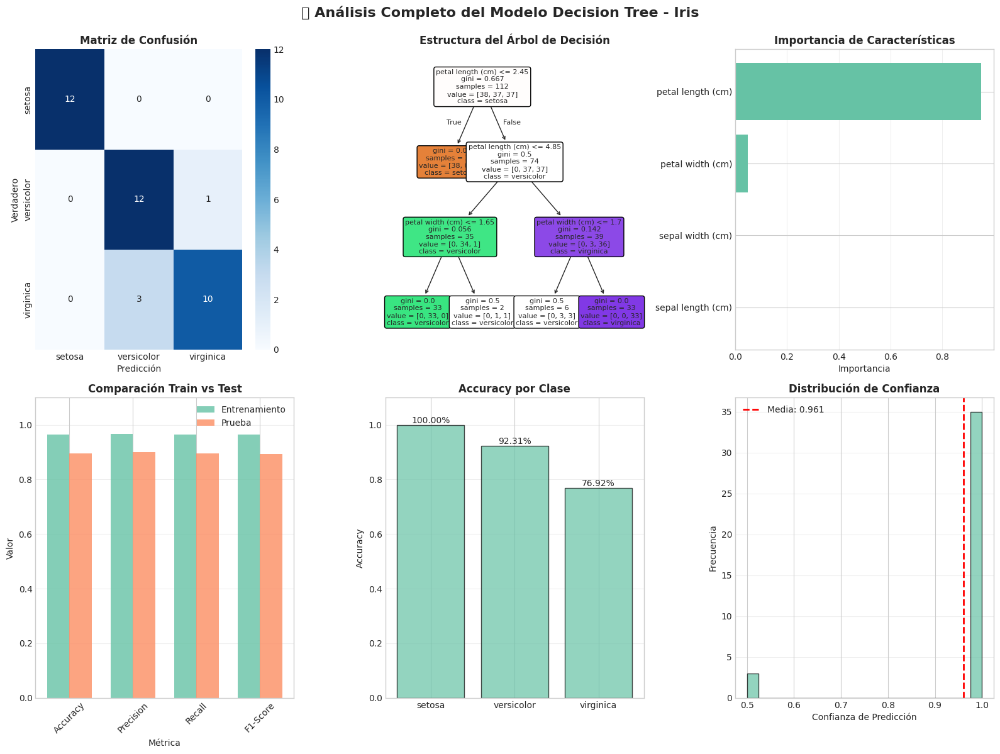

2026/09/28 09:11:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: c62faaa49537454bbfd943660d8e7c6f
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:11:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 4
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-d0ec658c115847b5965855e1b265d742?o=7474660565481428
2026/09/28 09:11:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:11:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-4ad5bb0ca1c24f239c1a95a96cb0b3f5?o=7474660565481428
2026/09/28 09:11:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:53 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:11:53 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-d01678d9ac0a4194b00f5413bc9b9cb9?o=7474660565481428
2026/09/28 09:11:57 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9678
      - Recall:    0.9643
      - F1-Score:  0.9642

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0695
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


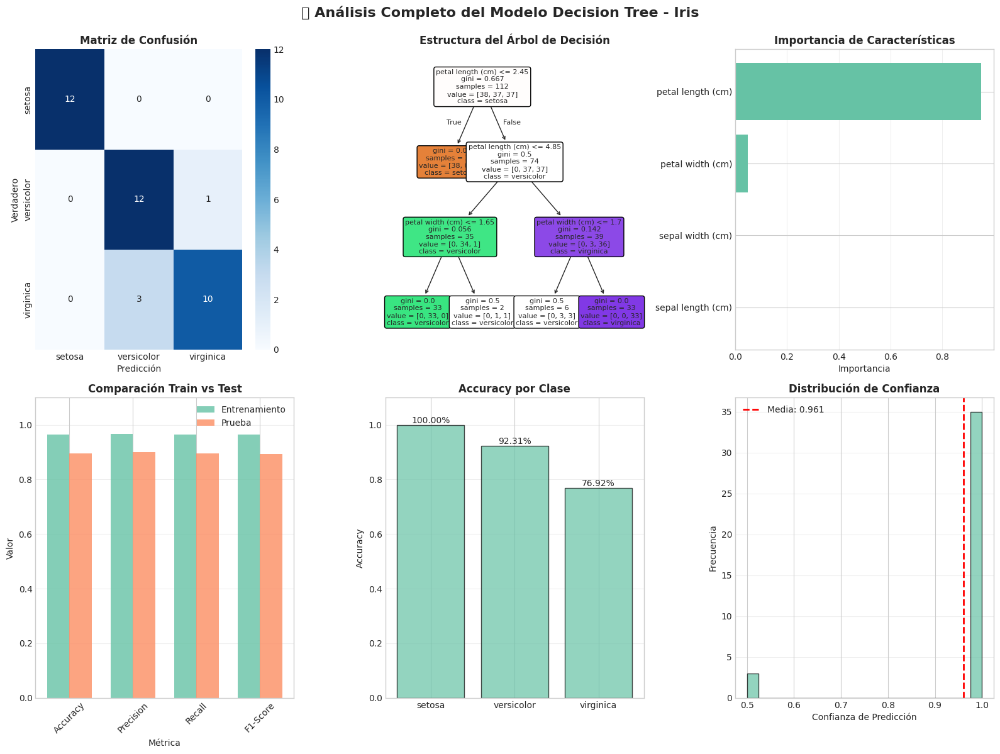

2026/09/28 09:12:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: e0adeaf6b5a440cfb5fceca9c6a40408
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:12:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: 4
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-b805f5eadfe2459dba9fa9cb379237d0?o=7474660565481428
2026/09/28 09:12:20 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:12:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-801964d593a2462086978ca14797c77b?o=7474660565481428
2026/09/28 09:12:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-7dc82b9f4d9d4f81990c7259048d137c?o=7474660565481428
2026/09/28 09:12:31 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9678
      - Recall:    0.9643
      - F1-Score:  0.9642

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0695
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


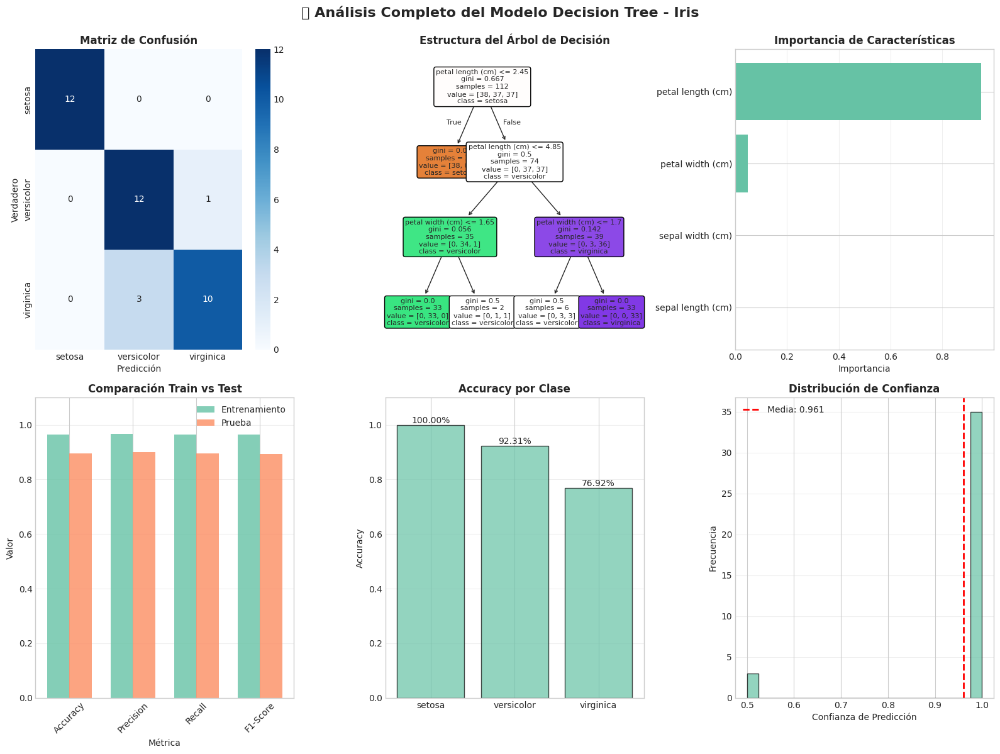

2026/09/28 09:12:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 7dadf5e2ad0942138a2c25ba72e3bc0f
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:12:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: sqrt
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9a69950f97d8471cb58089f0c94a5e54?o=7474660565481428
2026/09/28 09:12:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:12:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:12:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-8027bfb7135d4088bbebd6dedbdcc011?o=7474660565481428
2026/09/28 09:12:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-77240db942454d45a8a6b44260f78f9b?o=7474660565481428
2026/09/28 09:13:05 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


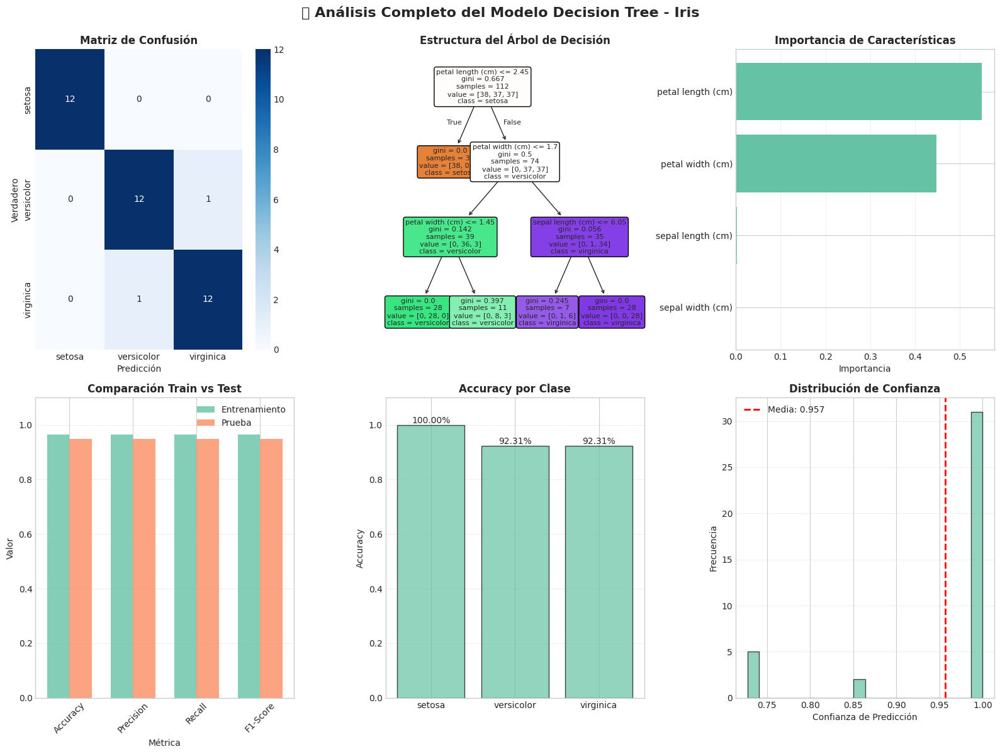

2026/09/28 09:13:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 4a6cea87dec84ef78136345a456170b3
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:13:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: sqrt
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-0541c9e4e0774fdaae3b87f81194c243?o=7474660565481428
2026/09/28 09:13:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:13:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e8886b8397654ede8ceb46227ea5dbff?o=7474660565481428
2026/09/28 09:13:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:13:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-4aa5b845019f4e58b3e26fb56f6bfe38?o=7474660565481428
2026/09/28 09:13:40 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


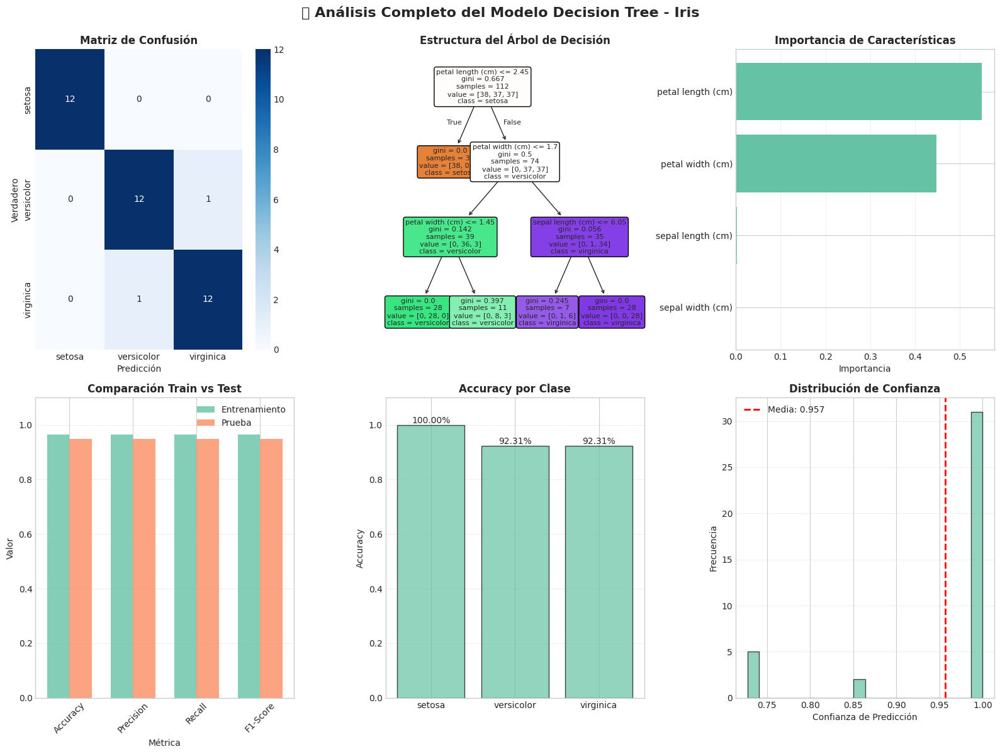

2026/09/28 09:14:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 9d3362666b644cd082177d8f07507a98
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:14:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 3
   - max_features: sqrt
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-69c97c000e3e4cd385acca8304d151f6?o=7474660565481428
2026/09/28 09:14:04 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:14:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-19cfe25cec8845618abbe92b0fa82fea?o=7474660565481428
2026/09/28 09:14:09 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-ca6117217d7849cb92140f97b5766e07?o=7474660565481428
2026/09/28 09:14:14 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9651
      - Recall:    0.9643
      - F1-Score:  0.9643

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9553 ± 0.0288

   ⚠️  Overfitting Score: 0.0169
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


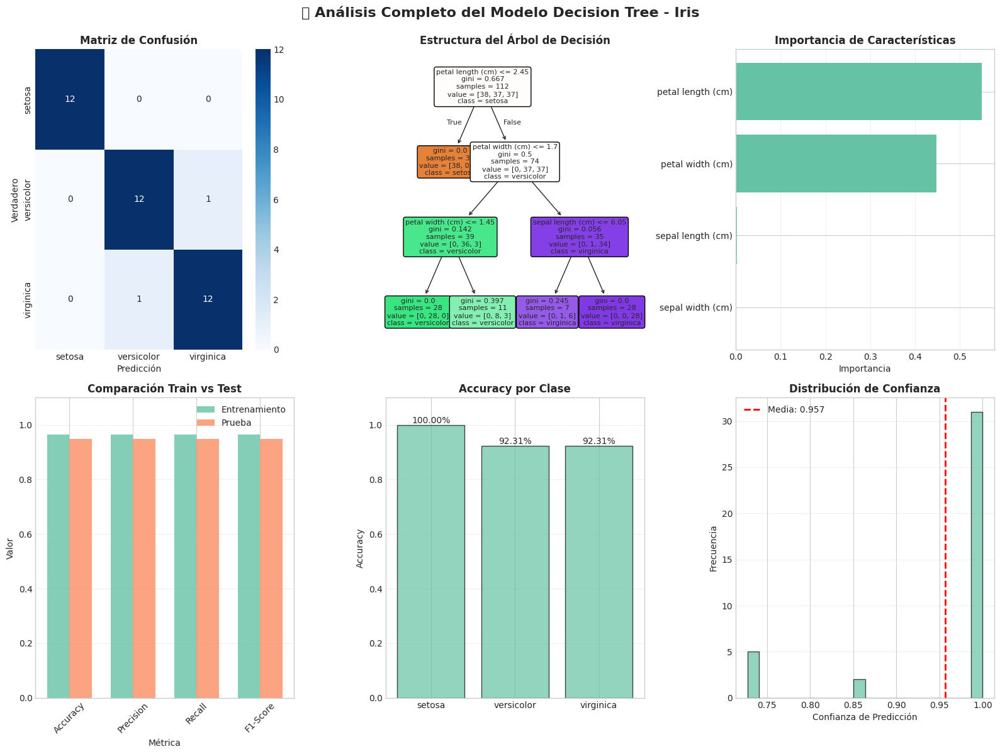

2026/09/28 09:14:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 23d88ac008de4fd5b851d3a027e3bc96
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9553 ± 0.0288
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:14:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 2
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-b20e8067c855477a991d421225fa3199?o=7474660565481428
2026/09/28 09:14:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:14:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-81596eda0254468795dabe4cabe76e4f?o=7474660565481428
2026/09/28 09:14:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:14:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-85e9df6d022b4ca1b7f68f0eb9fb3aac?o=7474660565481428
2026/09/28 09:14:49 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9281 ± 0.0620

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


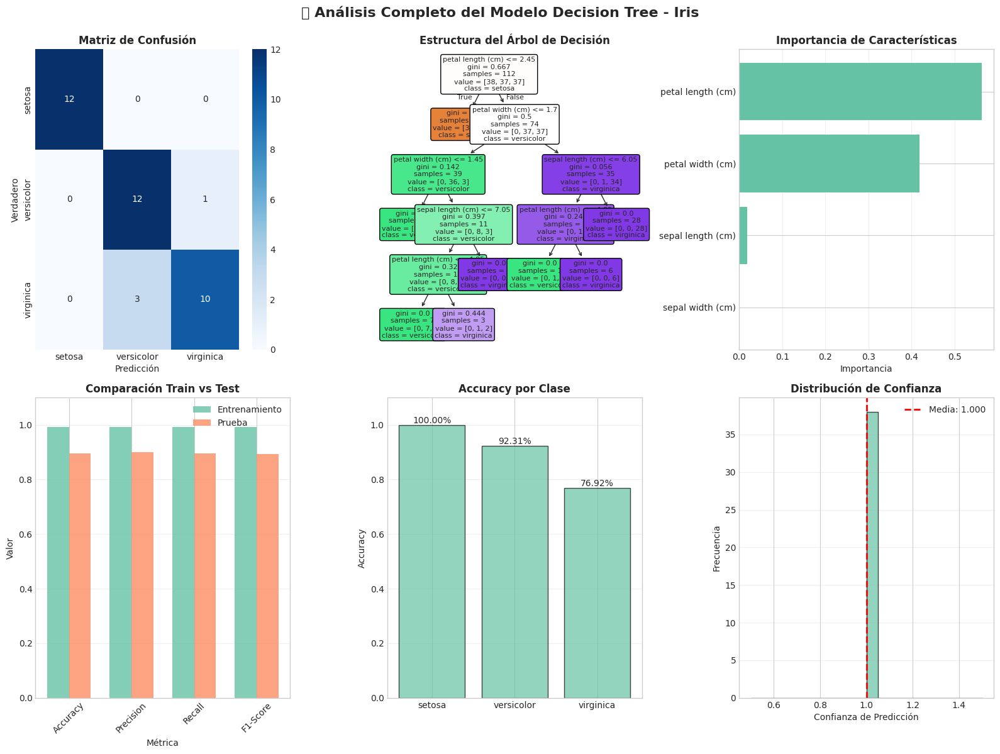

2026/09/28 09:15:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: be1fa432dfc64faa8161f08afb0b5725
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9281 ± 0.0620
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:15:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 2
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-4f6cd84589584fc8a6bf24a17349c50d?o=7474660565481428
2026/09/28 09:15:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:15:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-ffde7ae5ed3c430da7b3443ccb05a6e9?o=7474660565481428
2026/09/28 09:15:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5d98af60911c45c199c90a767e8ffcf1?o=7474660565481428
2026/09/28 09:15:28 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9281 ± 0.0620

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


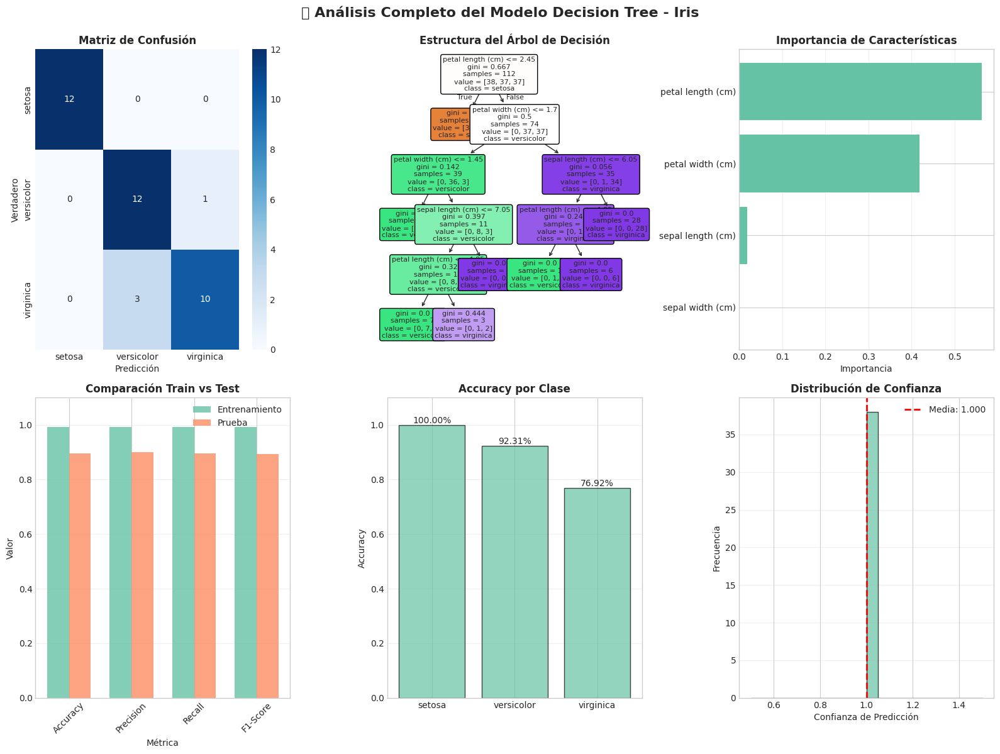

2026/09/28 09:15:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: ea73b9729ec54c5cb4897aa61f29445d
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9281 ± 0.0620
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:15:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 2
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-036c4d3092ec4fbc9a06514ad26b2a75?o=7474660565481428
2026/09/28 09:15:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:15:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


2026/09/28 09:15:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:15:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-73b7c917322f415b9c870b366913ca30?o=7474660565481428
2026/09/28 09:16:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9466 ± 0.0333

   ⚠️  Overfitting Score: 0.0348
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


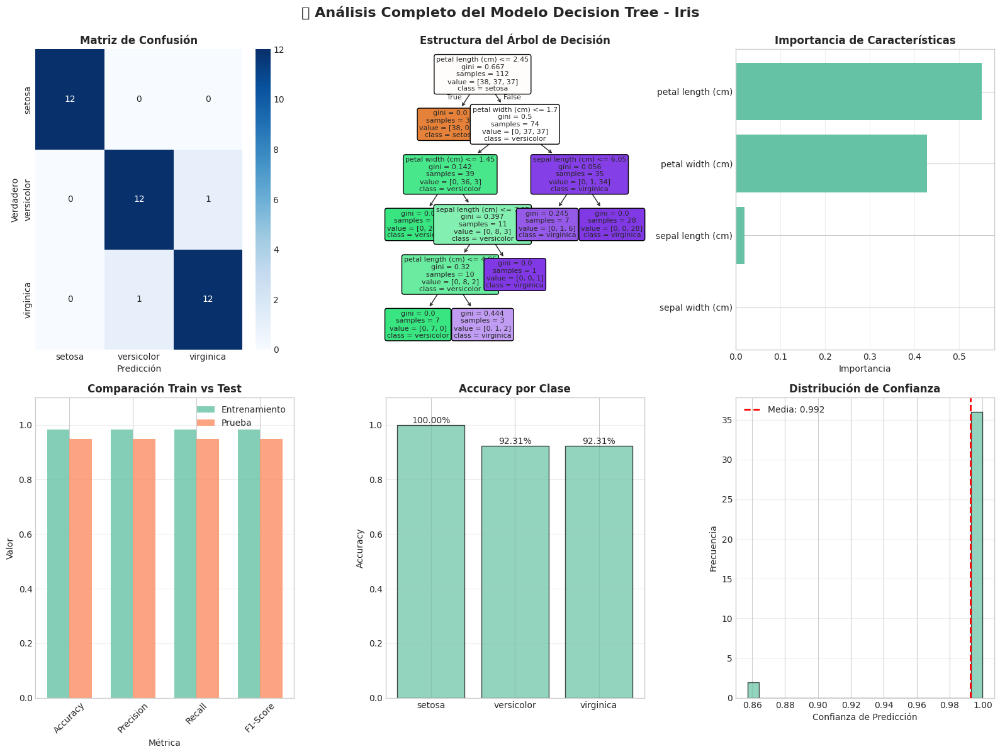

2026/09/28 09:16:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: e1379276f7114ed18f7b9cda1f397ae9
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9466 ± 0.0333
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:16:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 3
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9d2f6be455a0454abde1286494532aab?o=7474660565481428
2026/09/28 09:16:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:16:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1d6034d1e6464fe48fec707cc4866f2d?o=7474660565481428
2026/09/28 09:16:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:16:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-f3cad80f07624cba8a53d9ba5865d2dd?o=7474660565481428
2026/09/28 09:16:41 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0530

   ⚠️  Overfitting Score: 0.1053
      ⚠️  Cuidado - Posible overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


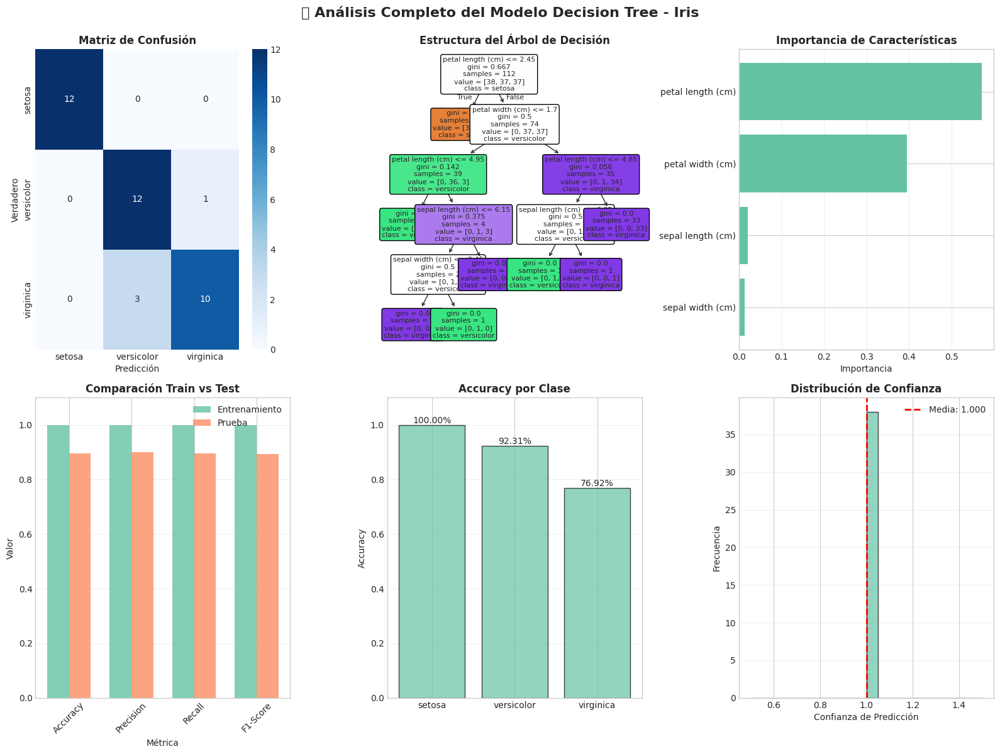

2026/09/28 09:17:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 8479ed2ff6e64be49c562eeb01da648a
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0530
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:17:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 3
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9fe20d3b45414dbe867ffe7adc342e22?o=7474660565481428
2026/09/28 09:17:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:17:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-8ca7abc5db8644ee87b41feb6a12b024?o=7474660565481428
2026/09/28 09:17:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:13 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-296146ca2b2d4ae689b21a9145574e41?o=7474660565481428
2026/09/28 09:17:18 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0174
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


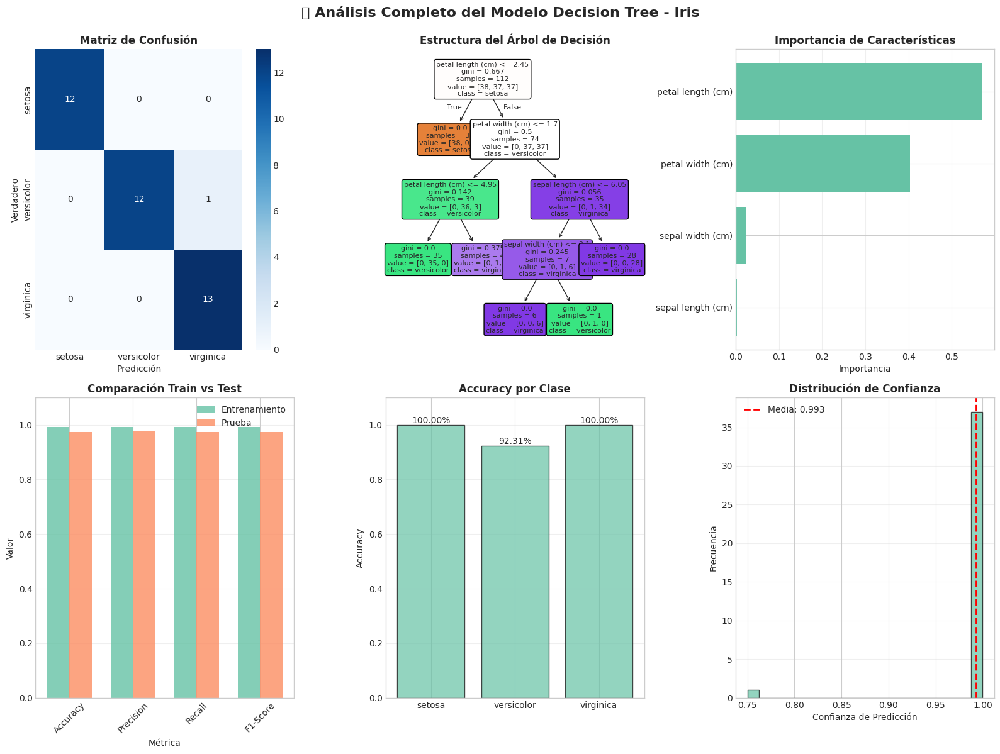

2026/09/28 09:17:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 35a3aa6472554afbaa11bae19b593a7f
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:17:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:17:54 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 3
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-74932cb006944e8a97bd5c3ee1cabe5b?o=7474660565481428
2026/09/28 09:17:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:18:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-14b6d1e3a4ca4feb8d92ca967b715b50?o=7474660565481428
2026/09/28 09:18:04 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-8de1fb9e7a6748068f898576ea496503?o=7474660565481428
2026/09/28 09:18:10 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


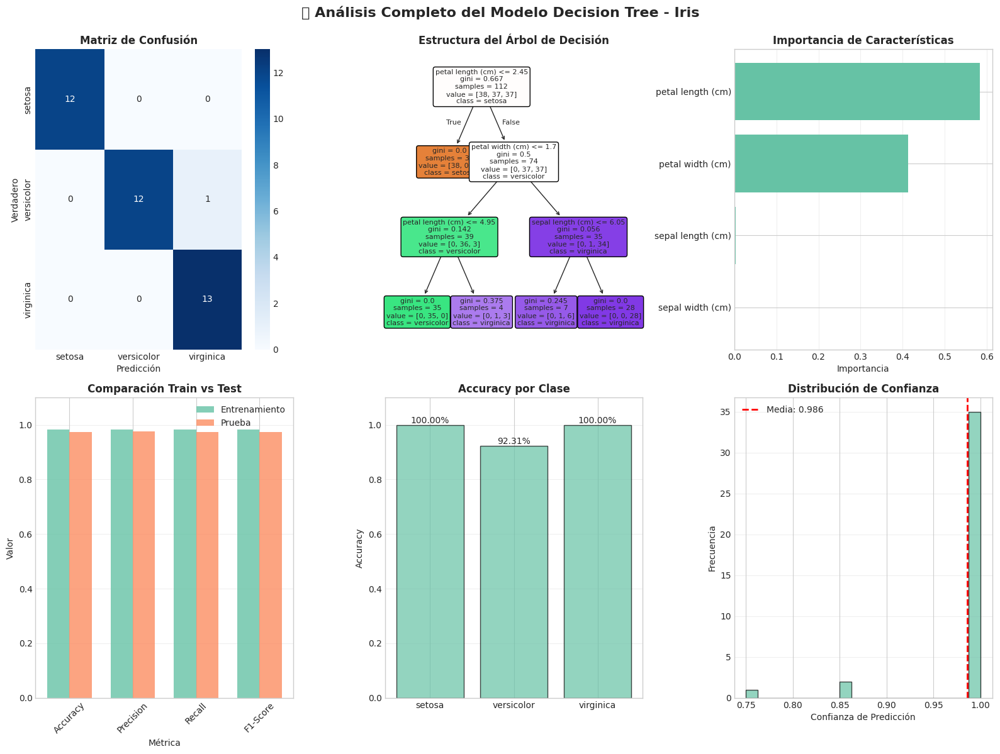

✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 83210c43625749678dfc73b9dfb131d9
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)


2026/09/28 09:18:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.



✅ Experimento finalizado correctamente
🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 4
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:18:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e129fde3f4d7424e8eb6651b540dcf70?o=7474660565481428
2026/09/28 09:18:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:18:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:41 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-f02e83da78844df19cada5e77355ff4f?o=7474660565481428
2026/09/28 09:18:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:18:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-c048f39e86dd4dd4b689a6eb4af9d4a5?o=7474660565481428
2026/09/28 09:18:53 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9292 ± 0.0444

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


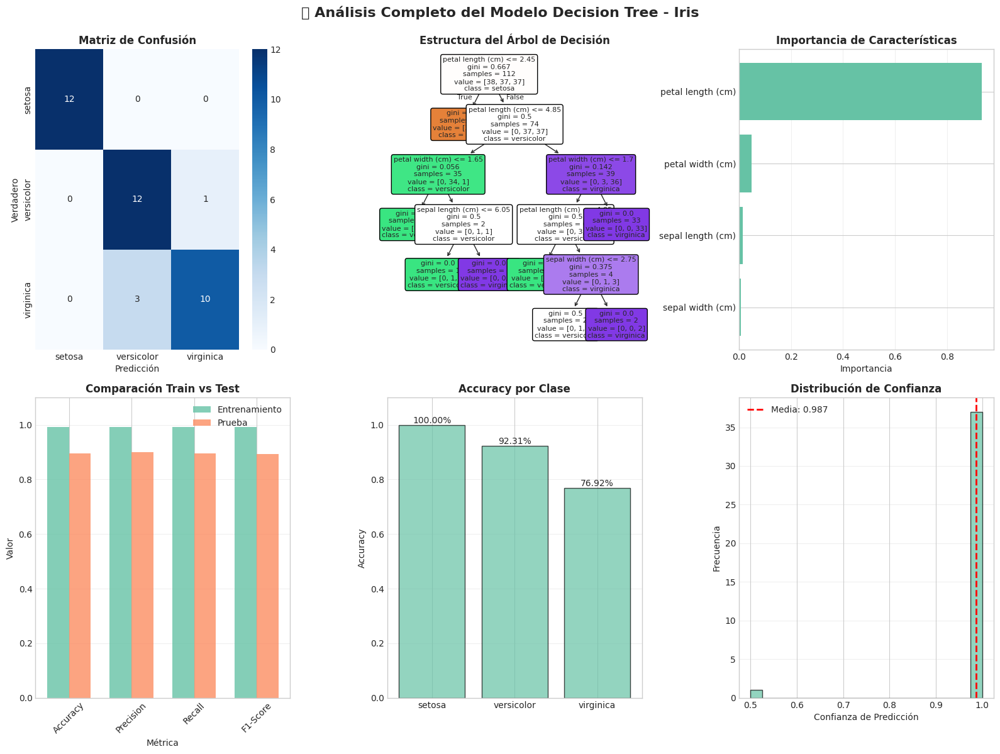

✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: c1d4338cc265412fa17bac7703a435f6
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9292 ± 0.0444
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:19:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 4
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:19:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-3b7d137ba0264c138b3f98b951208b63?o=7474660565481428
2026/09/28 09:19:29 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:19:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-352fe92e74c74018908d4ee71a24dab9?o=7474660565481428
2026/09/28 09:19:35 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:19:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1f83a95522b5418d858ff374c253c875?o=7474660565481428
2026/09/28 09:19:42 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9821
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9211 (92.11%)
      - Precision: 0.9226
      - Recall:    0.9211
      - F1-Score:  0.9209

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0611
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


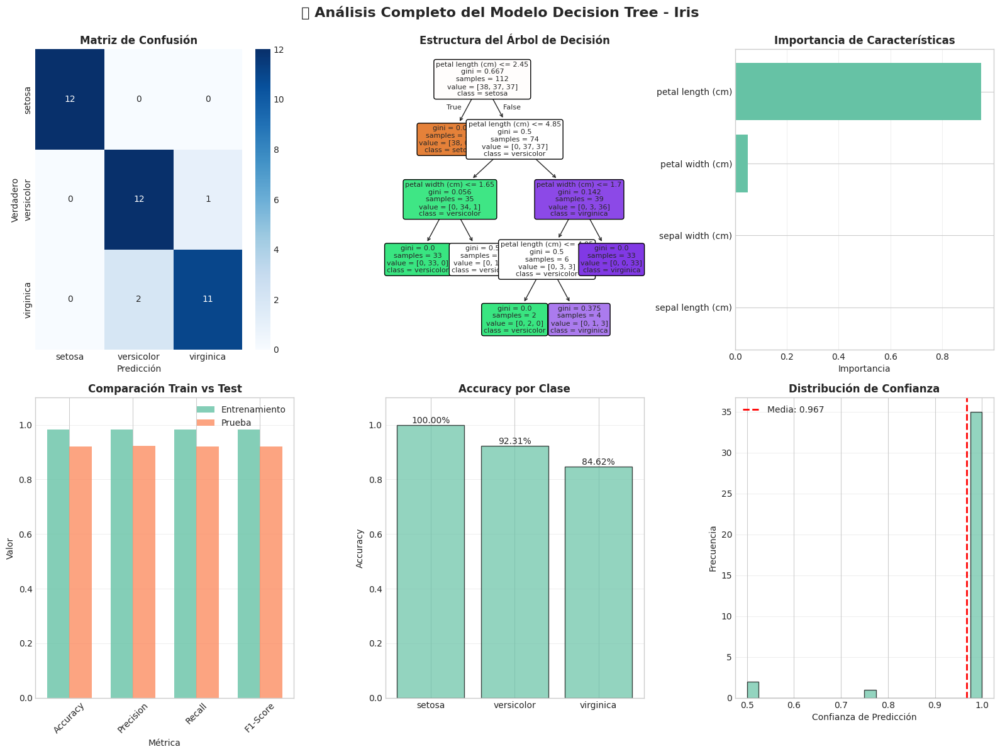

✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8571    0.9231    0.8889        13
   virginica     0.9167    0.8462    0.8800        13

    accuracy                         0.9211        38
   macro avg     0.9246    0.9231    0.9230        38
weighted avg     0.9226    0.9211    0.9209        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 8b1a2781d659438fb47d05083452299b
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9211 (92.11%)
🌟 F1-Score (Test): 0.9209
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:20:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 5
   - max_features: 4
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:20:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:20:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-d8affd0bca9345439a3ac60f307929a9?o=7474660565481428
2026/09/28 09:20:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:20:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


...

✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:25:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:25:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:25:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-ff756eb56f5743aea057b8f4d6add528?o=7474660565481428
2026/09/28 09:25:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:25:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:25:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e8f107e80f35473d9fff82c8b81c7c1d?o=7474660565481428
2026/09/28 09:25:53 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


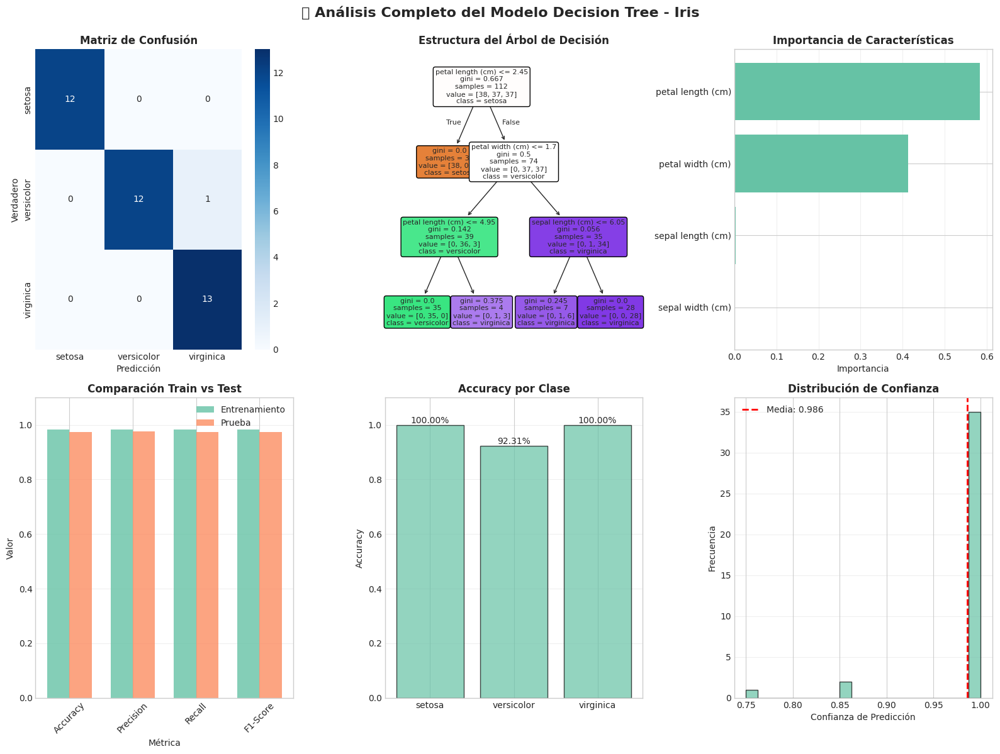

2026/09/28 09:26:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 149de46b929e46f4a69f4a11d1167585
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:26:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:12 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: 4
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e90a14ec755a478f9c876f62aea2fbdf?o=7474660565481428
2026/09/28 09:26:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:26:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e2d1a99427f64ef59e317e5b6748e260?o=7474660565481428
2026/09/28 09:26:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-38da424808b64108b4c13df0f14fc2f4?o=7474660565481428
2026/09/28 09:26:26 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9292 ± 0.0444

   ⚠️  Overfitting Score: 0.1053
      ⚠️  Cuidado - Posible overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


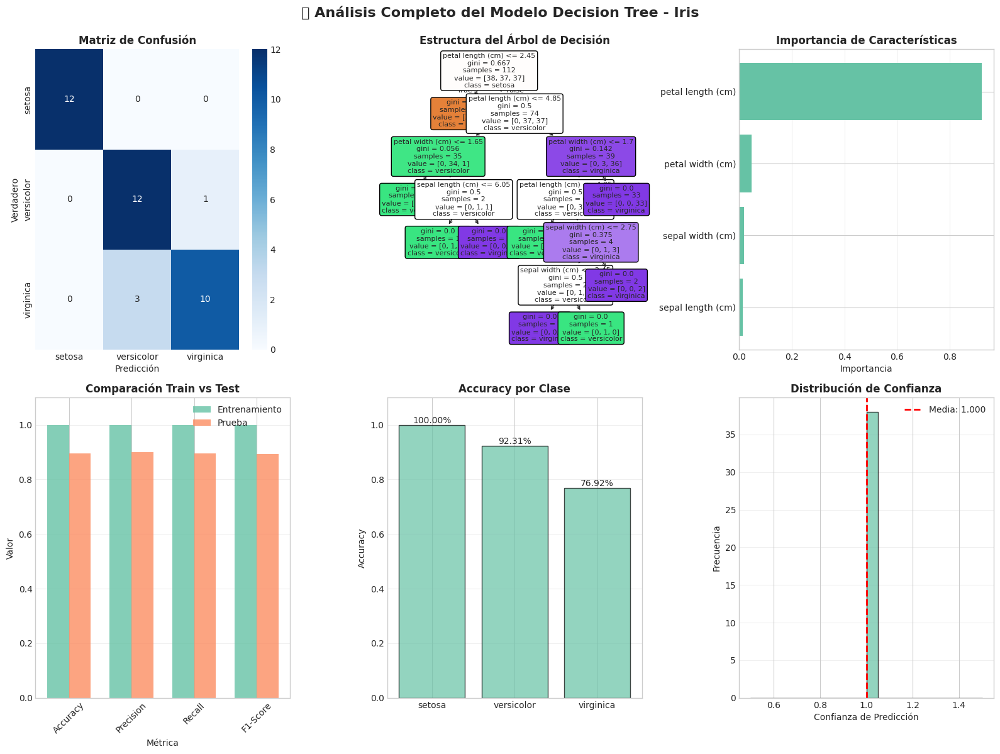

2026/09/28 09:26:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 5e02f0a638974b3c9bccc6cfe5f60ee6
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9292 ± 0.0444
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:26:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:47 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: 4
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-0a9e8a24b21e49d385fc98e5084886ea?o=7474660565481428
2026/09/28 09:26:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:26:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:52 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1777f0fd82f24dc58c225800c698a926?o=7474660565481428
2026/09/28 09:26:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:26:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-01db2c167b174f80a8eab08c370437ab?o=7474660565481428
2026/09/28 09:27:01 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9821
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9211 (92.11%)
      - Precision: 0.9226
      - Recall:    0.9211
      - F1-Score:  0.9209

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0611
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


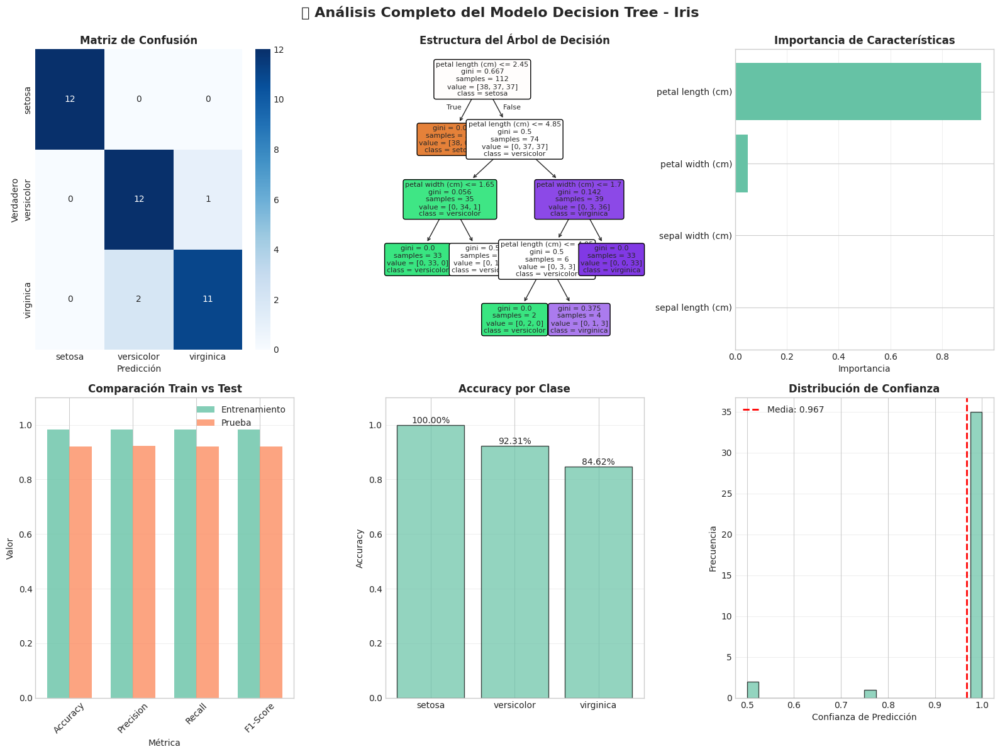

2026/09/28 09:27:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8571    0.9231    0.8889        13
   virginica     0.9167    0.8462    0.8800        13

    accuracy                         0.9211        38
   macro avg     0.9246    0.9231    0.9230        38
weighted avg     0.9226    0.9211    0.9209        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 2c5dcae88a6f48eb88446cab9b2678aa
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9211 (92.11%)
🌟 F1-Score (Test): 0.9209
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:27:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: 4
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-c9bb600e9f984af495c9a824cebfc41c?o=7474660565481428
2026/09/28 09:27:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:27:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-7b819db962924f87bd4e3a8b6935b0df?o=7474660565481428
2026/09/28 09:27:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-fb7e20b67ebf4d3b88c6e4e45f359449?o=7474660565481428
2026/09/28 09:27:36 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9678
      - Recall:    0.9643
      - F1-Score:  0.9642

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0695
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


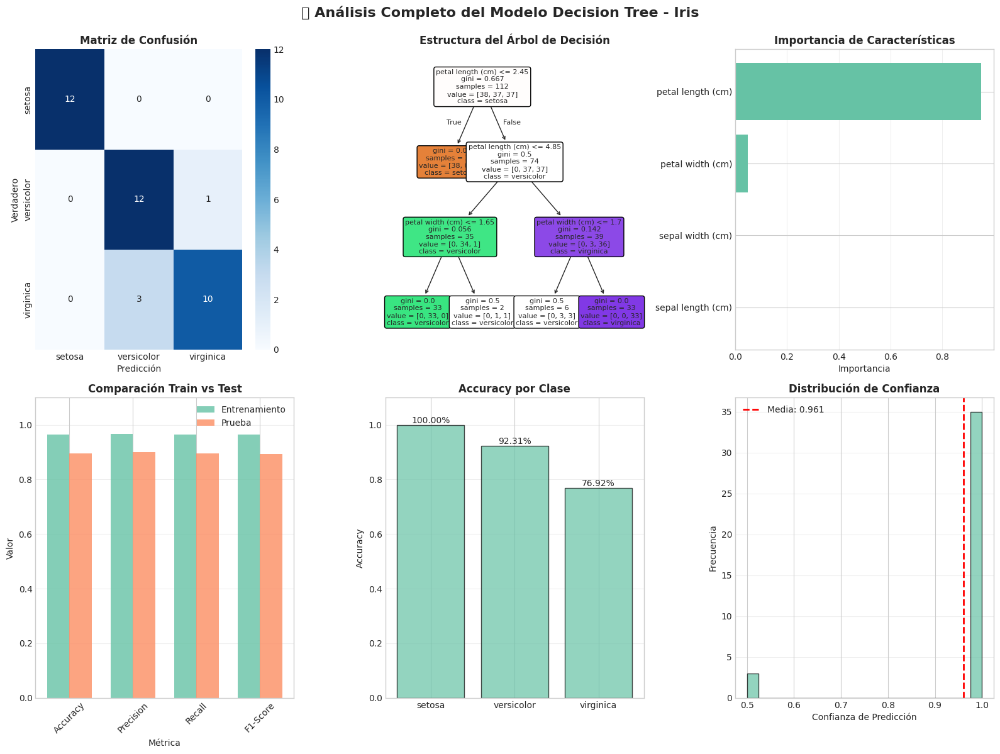

2026/09/28 09:27:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: b380a862bd6d4c52bd79fe67d603dda3
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:27:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:27:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: sqrt
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1a06b4a2a86d442993876682b2c9018b?o=7474660565481428
2026/09/28 09:27:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:28:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-ad465c939e78419d80ac3f7e3ee2480f?o=7474660565481428
2026/09/28 09:28:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-121099366c3246259f91b5ff45d876f4?o=7474660565481428
2026/09/28 09:28:10 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9194 ± 0.0604

   ⚠️  Overfitting Score: 0.0526
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


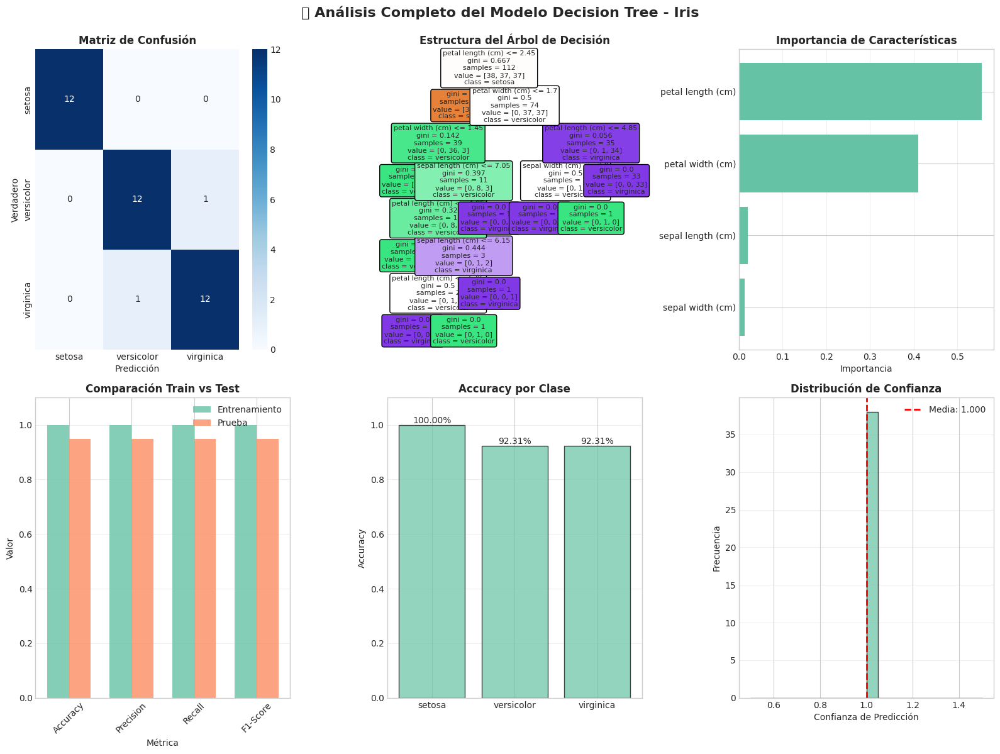

2026/09/28 09:28:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 2afb75b29d364769b6ac34bf00e6a1ec
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9194 ± 0.0604
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:28:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:32 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: sqrt
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-50b333951e504e64b485293bcf0fd70d?o=7474660565481428
2026/09/28 09:28:36 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:28:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:37 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-83f7bae71f494be9bddf3aa280c98961?o=7474660565481428
2026/09/28 09:28:41 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:42 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:28:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-7364945e4c0e485494ee9fe1ff790ea2?o=7474660565481428
2026/09/28 09:28:46 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9281 ± 0.0620

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


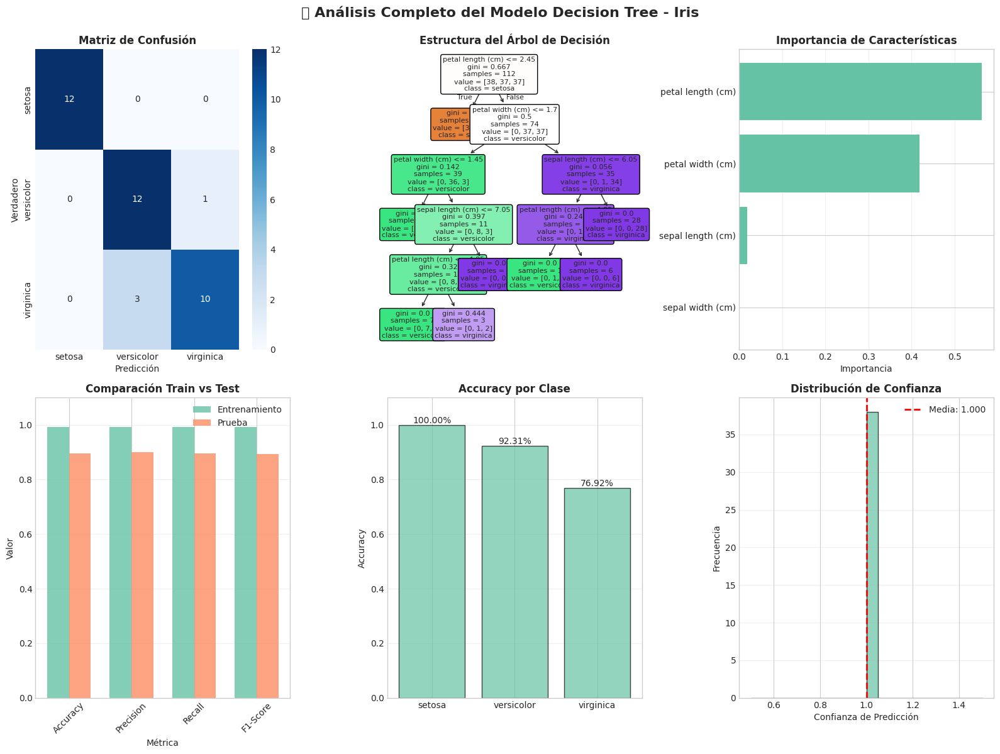

2026/09/28 09:29:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: e9f62afd2b494a8e91af92c7bec28da9
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9281 ± 0.0620
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:29:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: 10
   - max_features: sqrt
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9a1d04f0c8cf4adc953a64965b8a3597?o=7474660565481428
2026/09/28 09:29:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:29:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-45816a30cea248e8baa6aa25761a10a4?o=7474660565481428
2026/09/28 09:29:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-87bb6636836f48daa6a8bd3a50f36502?o=7474660565481428
2026/09/28 09:29:20 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9466 ± 0.0333

   ⚠️  Overfitting Score: 0.0348
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


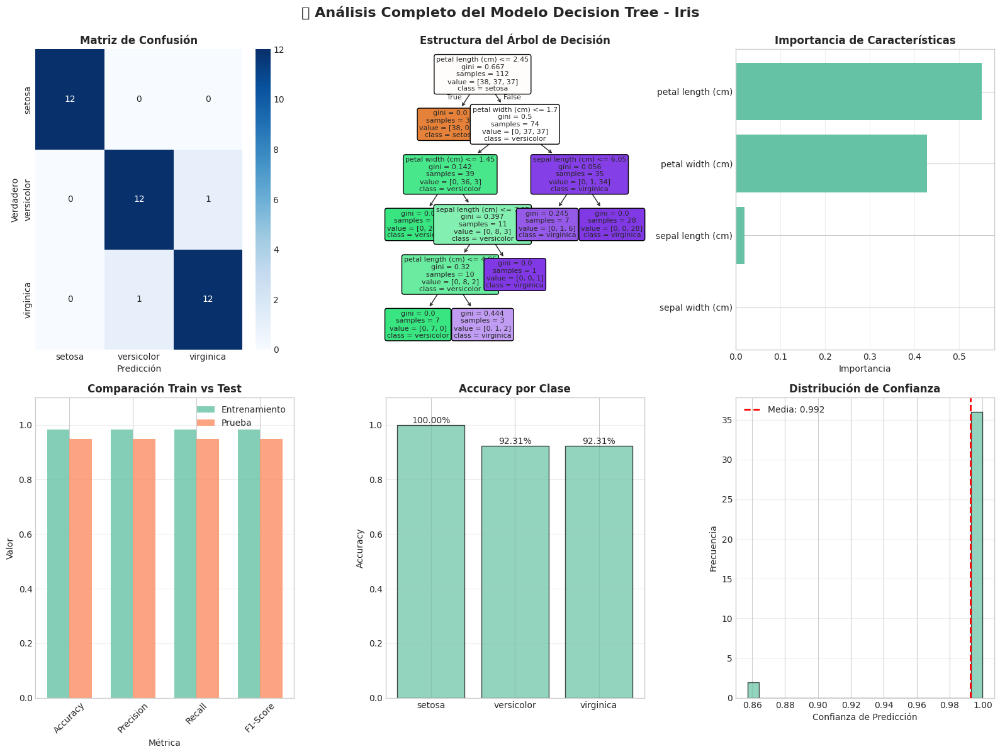

2026/09/28 09:29:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 5c49bf54eeb54f848f27f29f65ff9756
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9466 ± 0.0333
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:29:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 2
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5d7467ba640f491d8c63ad6955d5f2f5?o=7474660565481428
2026/09/28 09:29:44 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:29:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-db4b92768f0f4a3bbf28ec06ec624afa?o=7474660565481428
2026/09/28 09:29:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:29:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-193689bd45834984a31134abc8cd6400?o=7474660565481428
2026/09/28 09:29:55 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9194 ± 0.0604

   ⚠️  Overfitting Score: 0.0526
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


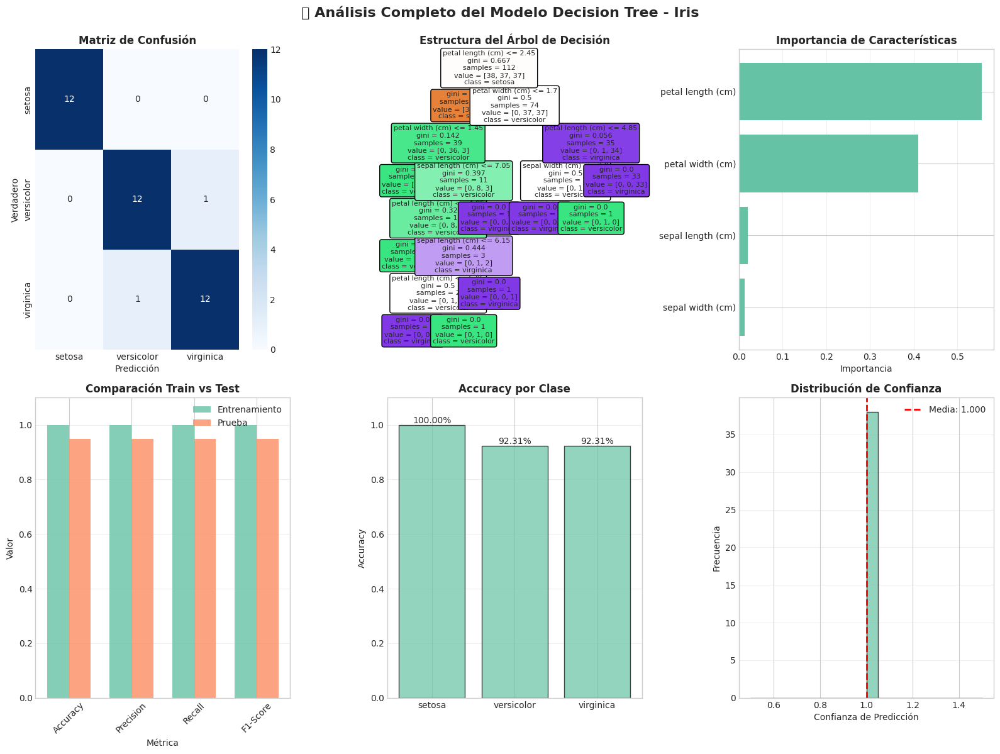

2026/09/28 09:30:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 0d7e7dfc131f4c83bbb387c74fc296bf
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9194 ± 0.0604
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:30:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 2
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-db67dbe23bc04094a3fcb45c274a4529?o=7474660565481428
2026/09/28 09:30:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:30:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


2026/09/28 09:30:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-895680ab85f64ff484ffda4a2b1d386a?o=7474660565481428
2026/09/28 09:30:27 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:30:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9281 ± 0.0620

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


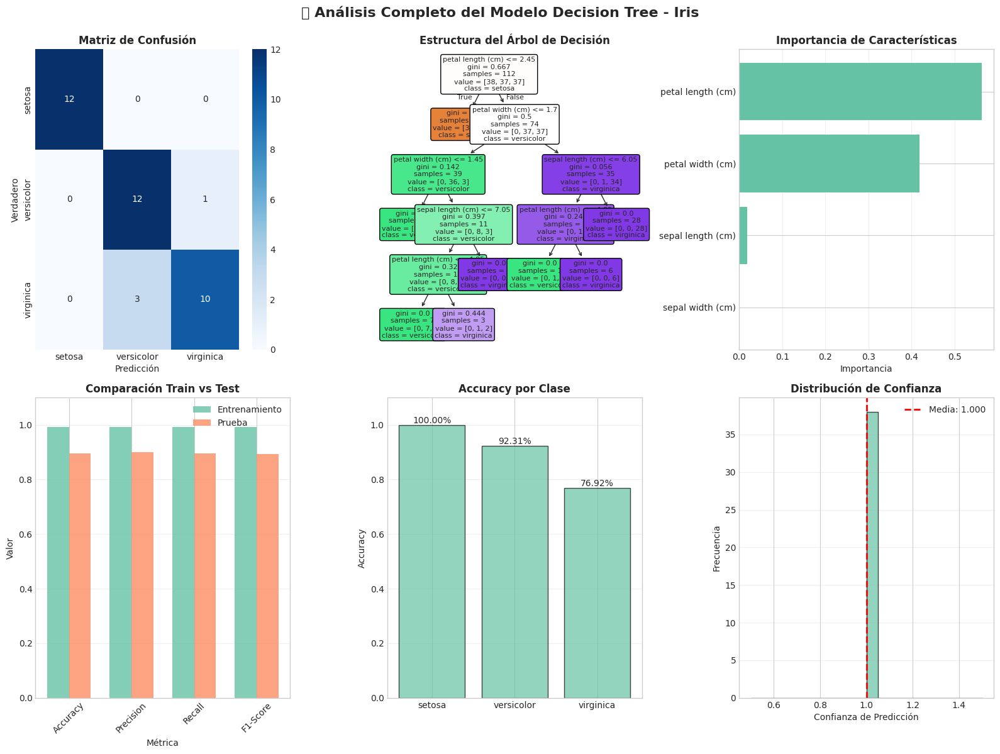

2026/09/28 09:31:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: c65740dbbe0c4c208aaa0999b9acf65e
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9281 ± 0.0620
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:31:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 2
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9ddedbf831094617aae467482492a0b4?o=7474660565481428
2026/09/28 09:31:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:31:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-6e73fdc8c1a947e1bcc21f3297aadf39?o=7474660565481428
2026/09/28 09:31:23 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:31:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5777103dc47f4c72bddf58c2e469c917?o=7474660565481428
2026/09/28 09:31:29 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9466 ± 0.0333

   ⚠️  Overfitting Score: 0.0348
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


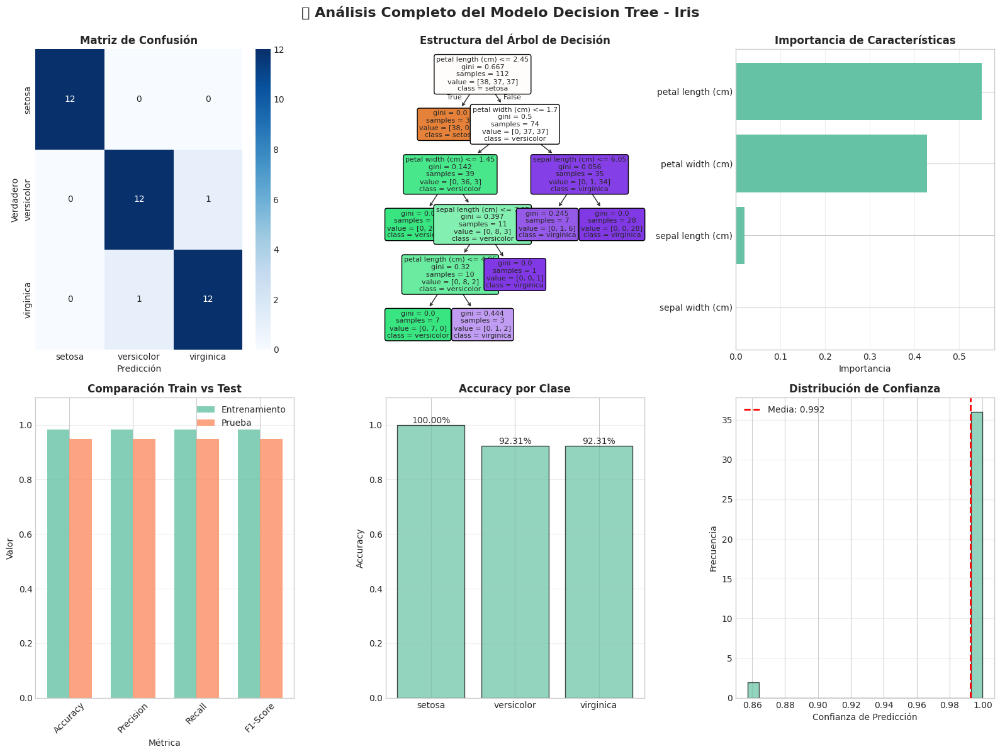

2026/09/28 09:31:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: d169ef6e03c142cbada723b63f6c75bb
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9466 ± 0.0333
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:31:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 3
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:31:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-03adb255e455421eb13d21a82ba29de0?o=7474660565481428
2026/09/28 09:32:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:32:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:03 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-89d2ae22d1524b0581180ffd64e53848?o=7474660565481428
2026/09/28 09:32:07 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:09 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:09 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1f9b6d3140f343969a9194c70ab8042e?o=7474660565481428
2026/09/28 09:32:13 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0530

   ⚠️  Overfitting Score: 0.1053
      ⚠️  Cuidado - Posible overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


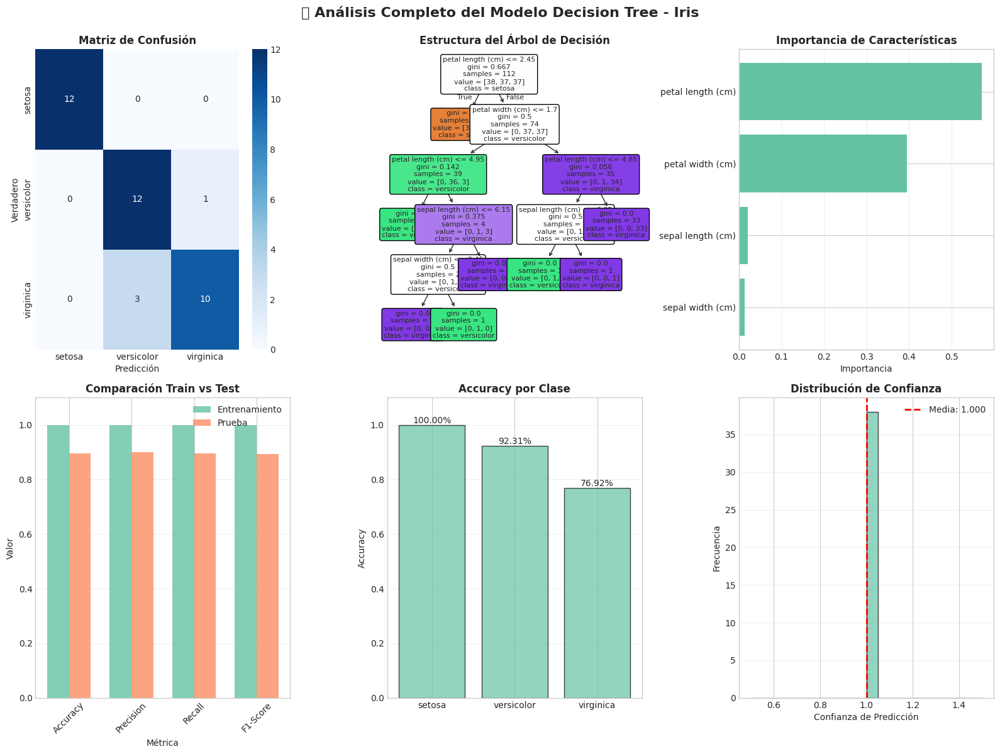

2026/09/28 09:32:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 4bc79401664644c29c2053f62ae9e62d
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0530
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:32:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:34 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 3
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-cd83990a166e4001916e3741157e37a9?o=7474660565481428
2026/09/28 09:32:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:32:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-4d3cfbf7f79043b8b1b3635ad3716807?o=7474660565481428
2026/09/28 09:32:43 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:32:45 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-fe7a0de925b34d94b5a77ac895f70911?o=7474660565481428
2026/09/28 09:32:49 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0174
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


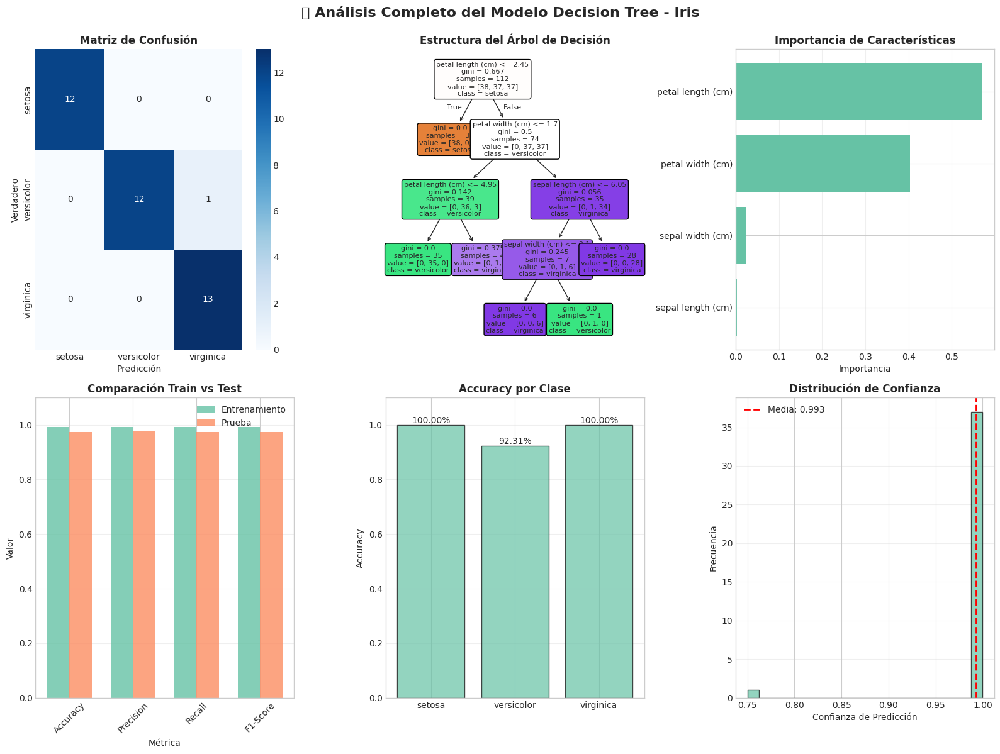

2026/09/28 09:33:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 093c4d6566be499cb4eac6f585a30901
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:33:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:08 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 3
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-85b836f8d6094421a12aa85824e2edc9?o=7474660565481428
2026/09/28 09:33:14 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:33:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:15 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-9a7d9df7e1354e0dbacfce3e43073a2a?o=7474660565481428
2026/09/28 09:33:20 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-396499871d0a42a6b0937f6e62ef9037?o=7474660565481428
2026/09/28 09:33:25 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9737 (97.37%)
      - Precision: 0.9756
      - Recall:    0.9737
      - F1-Score:  0.9736

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9462 ± 0.0439

   ⚠️  Overfitting Score: 0.0085
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


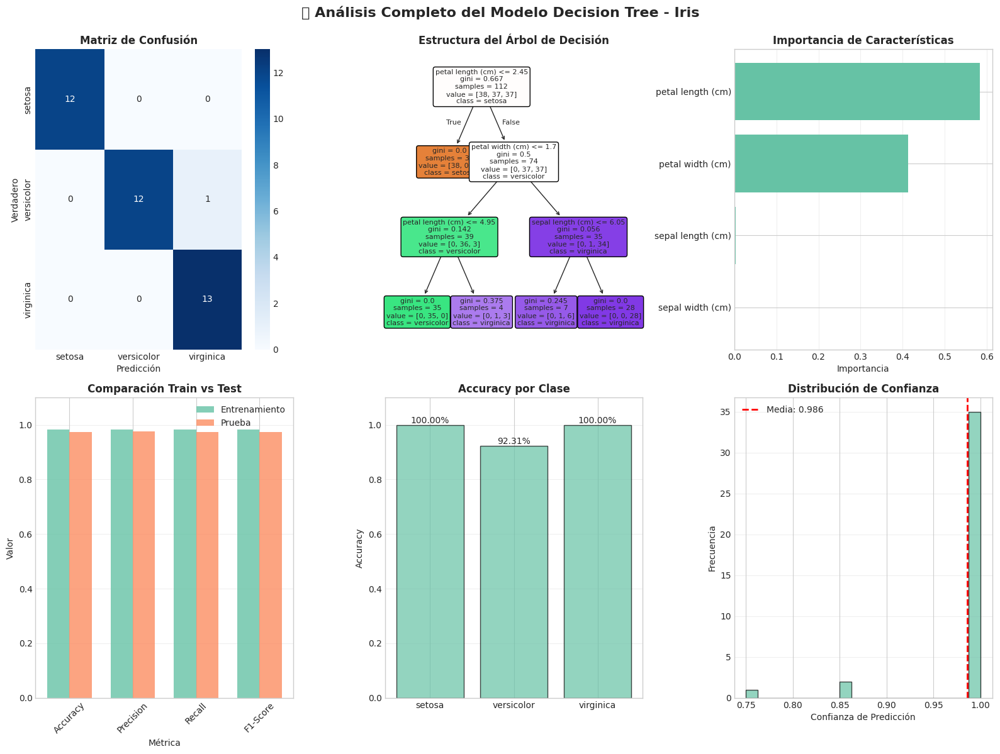

2026/09/28 09:33:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     1.0000    0.9231    0.9600        13
   virginica     0.9286    1.0000    0.9630        13

    accuracy                         0.9737        38
   macro avg     0.9762    0.9744    0.9743        38
weighted avg     0.9756    0.9737    0.9736        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: ce6889d1ad674e59a7e1e49577294e6a
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9737 (97.37%)
🌟 F1-Score (Test): 0.9736
📊 Cross-Val Accuracy: 0.9462 ± 0.0439
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:33:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:49 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 4
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e8857fe2506e4732ad98a8773c9da044?o=7474660565481428
2026/09/28 09:33:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:33:56 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5ebc2c69352241ef9be285e3a6017077?o=7474660565481428
2026/09/28 09:34:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:02 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-e6d6db355aaf4de484e40965b3a05091?o=7474660565481428
2026/09/28 09:34:08 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9292 ± 0.0444

   ⚠️  Overfitting Score: 0.1053
      ⚠️  Cuidado - Posible overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


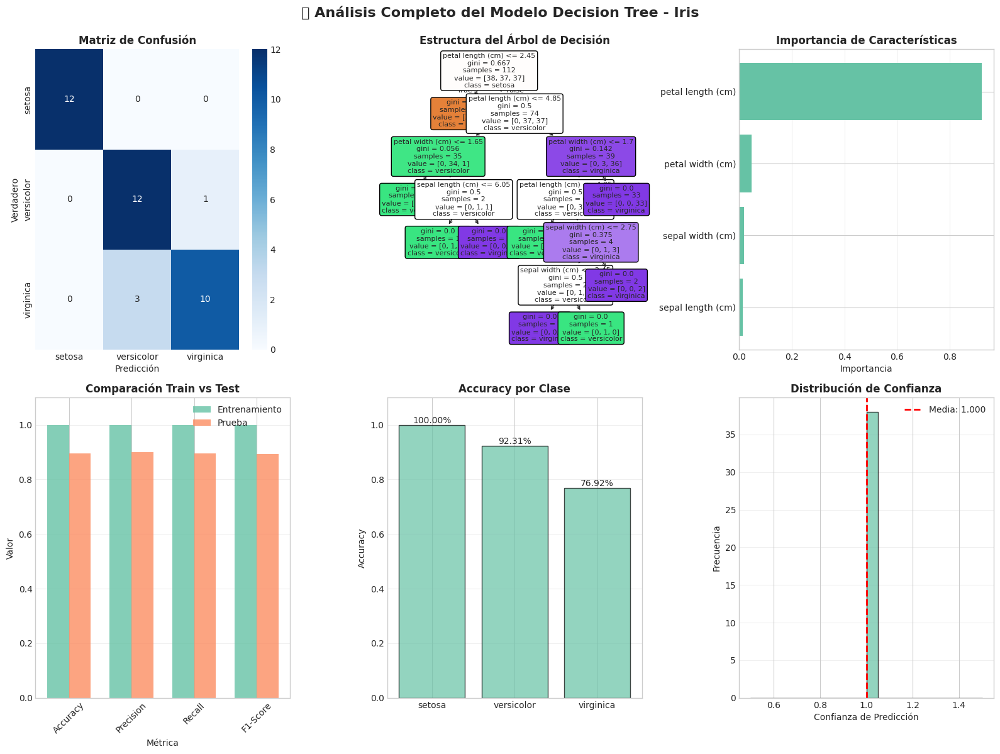

2026/09/28 09:34:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 1fc341179ade4ab1ad4a2b0aa695d307
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9292 ± 0.0444
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:34:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:46 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 4
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-67e1e25c9fd0499093006e669ea781a0?o=7474660565481428
2026/09/28 09:34:50 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:34:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-95ec0eb440c247c6b838597911447fc6?o=7474660565481428
2026/09/28 09:34:57 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:34:58 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-62284bee37004833a3e549cca119f32e?o=7474660565481428
2026/09/28 09:35:02 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9821
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9211 (92.11%)
      - Precision: 0.9226
      - Recall:    0.9211
      - F1-Score:  0.9209

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0611
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


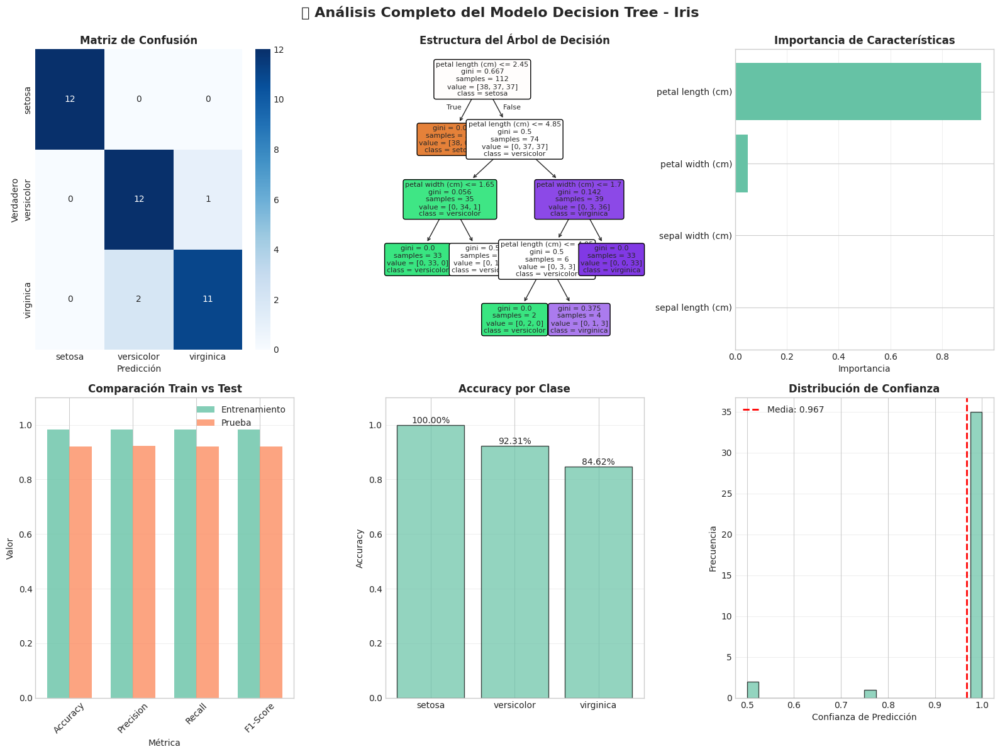

✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8571    0.9231    0.8889        13
   virginica     0.9167    0.8462    0.8800        13

    accuracy                         0.9211        38
   macro avg     0.9246    0.9231    0.9230        38
weighted avg     0.9226    0.9211    0.9209        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: a29c22e65d6a459ea324de86d15bf891
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9211 (92.11%)
🌟 F1-Score (Test): 0.9209
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:35:30 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: 4
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:35:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:35:31 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-56f09663c54e4fc89af8f9bcab673191?o=7474660565481428
2026/09/28 09:35:38 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:35:39 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:35:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:35:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


2026/09/28 09:35:40 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:35:41 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-70c37846a6aa484c80e443d1a64dfb43?o=7474660565481428
2026/09/28 09:35:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:35:51 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9643 (96.43%)
      - Precision: 0.9678
      - Recall:    0.9643
      - F1-Score:  0.9642

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9375 ± 0.0360

   ⚠️  Overfitting Score: 0.0695
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


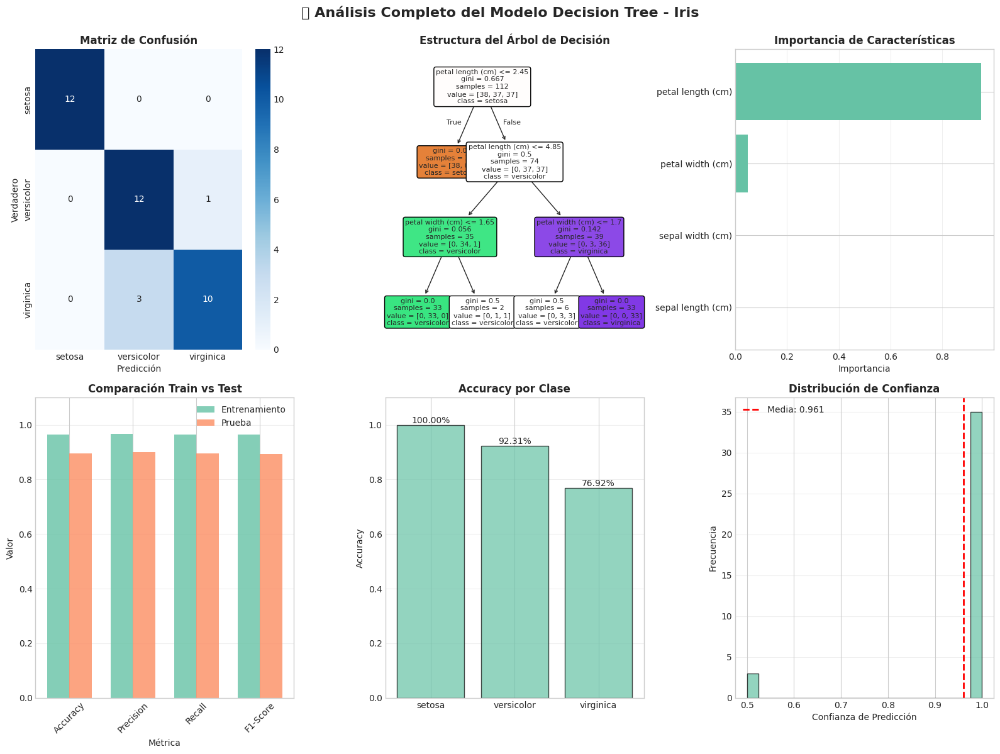

2026/09/28 09:36:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 5e089379548048e6889adf40448980ba
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9375 ± 0.0360
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:36:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: sqrt
   - min_samples_split: 2

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-930f1b2f0d624ee79a1534cc13dc8880?o=7474660565481428
2026/09/28 09:36:20 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:36:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:21 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-5c01d49203724b5b96d0f6dd9d2604f0?o=7474660565481428
2026/09/28 09:36:25 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:36:26 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-79ba97c8afdc443587dd5275a9a3028c?o=7474660565481428
2026/09/28 09:36:31 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  1.0000 (100.00%)
      - Precision: 1.0000
      - Recall:    1.0000
      - F1-Score:  1.0000

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9194 ± 0.0604

   ⚠️  Overfitting Score: 0.0526
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


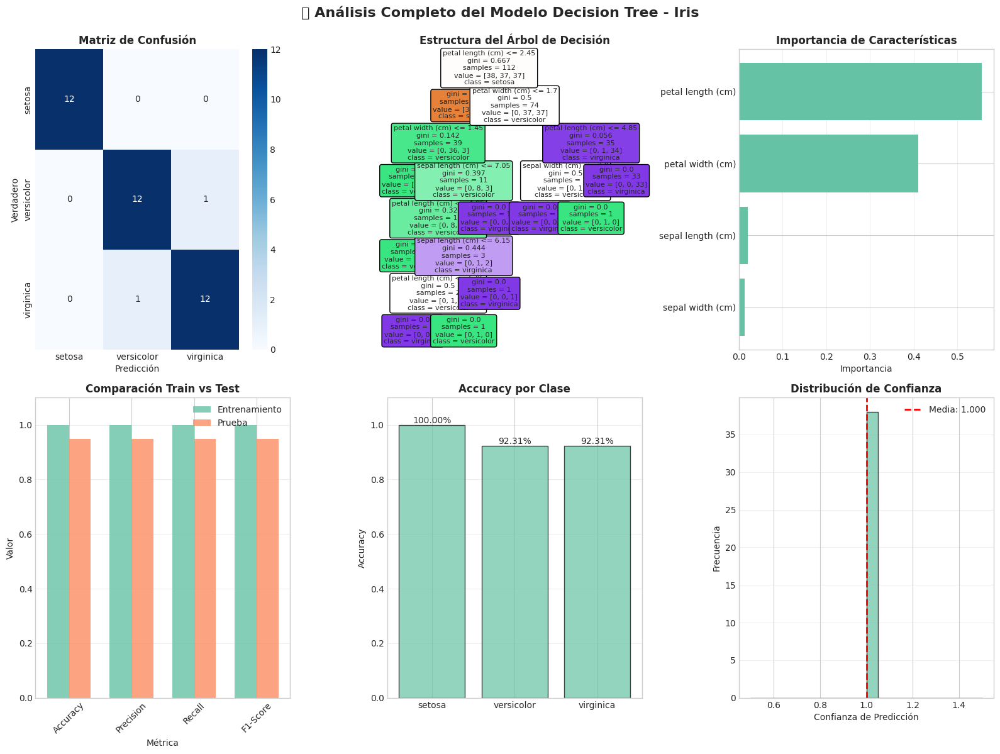

2026/09/28 09:37:10 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: ddd586bd3a664883ad501ab37473ebeb
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9194 ± 0.0604
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente
🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: sqrt
   - min_samples_split: 5

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


2026/09/28 09:37:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:11 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-08c38419efa24d549b1c5f35ea7531a9?o=7474660565481428
2026/09/28 09:37:16 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:17 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not availabl

✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:37:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:18 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1ce21bc99e414d099b707e6c0e14814b?o=7474660565481428
2026/09/28 09:37:22 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:24 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-a686f9414387423aa03f14d52f9e896c?o=7474660565481428
2026/09/28 09:37:27 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9911 (99.11%)
      - Precision: 0.9913
      - Recall:    0.9911
      - F1-Score:  0.9911

   🧪 PRUEBA:
      - Accuracy:  0.8947 (89.47%)
      - Precision: 0.9005
      - Recall:    0.8947
      - F1-Score:  0.8941

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9281 ± 0.0620

   ⚠️  Overfitting Score: 0.0963
      ⚡ Bueno - Overfitting moderado

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


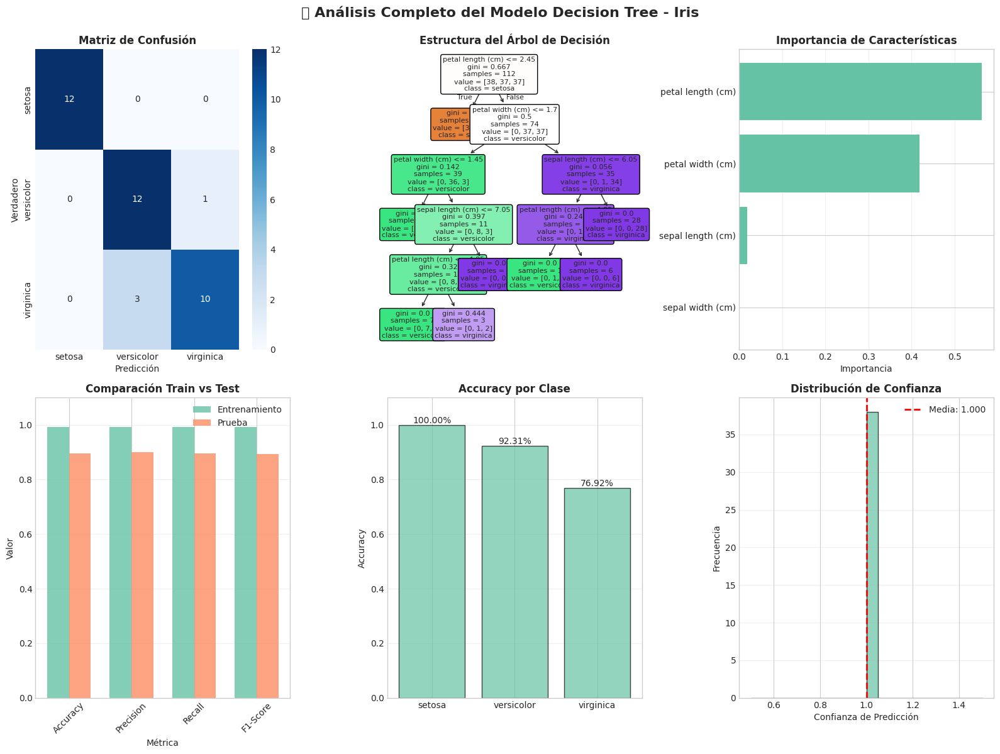

2026/09/28 09:37:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.8000    0.9231    0.8571        13
   virginica     0.9091    0.7692    0.8333        13

    accuracy                         0.8947        38
   macro avg     0.9030    0.8974    0.8968        38
weighted avg     0.9005    0.8947    0.8941        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: 82a0f5561fbd4d5488165cb53c94b1aa
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.8947 (89.47%)
🌟 F1-Score (Test): 0.8941
📊 Cross-Val Accuracy: 0.9281 ± 0.0620
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


2026/09/28 09:37:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:37:55 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN

⚙️  HIPERPARÁMETROS:
   - max_depth: None
   - max_features: sqrt
   - min_samples_split: 10

🌳 Creando Árbol de Decisión...
📚 Entrenando con 112 muestras...


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-1d1e028bb5e94a548b139c8aaa862966?o=7474660565481428
2026/09/28 09:37:59 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Modelo entrenado exitosamente

🔮 Realizando predicciones...


2026/09/28 09:38:00 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:01 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.


✅ Predicciones completadas

📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:


🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-cf5a35ebdb1d42e4a6f33381e170dd52?o=7474660565481428
2026/09/28 09:38:05 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
2026/09/28 09:38:06 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: getContext().extraContext() is not a CommandContext accessor, it is not available or is misspelled.
🔗 View Logged Model at: https://dbc-1c61573e-a96a.cloud.databricks.com/ml/experiments/2781564230117224/models/m-d8b67e99b43b4724a52bdc445c75a3e0?o=7474660565481428
2026/09/28 09:38:10 WARNING ml


   📚 ENTRENAMIENTO:
      - Accuracy:  0.9821 (98.21%)
      - Precision: 0.9831
      - Recall:    0.9821
      - F1-Score:  0.9821

   🧪 PRUEBA:
      - Accuracy:  0.9474 (94.74%)
      - Precision: 0.9474
      - Recall:    0.9474
      - F1-Score:  0.9474

   🔄 CROSS-VALIDATION (5-fold):
      - Mean Accuracy: 0.9466 ± 0.0333

   ⚠️  Overfitting Score: 0.0348
      ✅ Excelente - Poco overfitting

📝 Registrando información en MLflow...

📈 Generando visualizaciones...


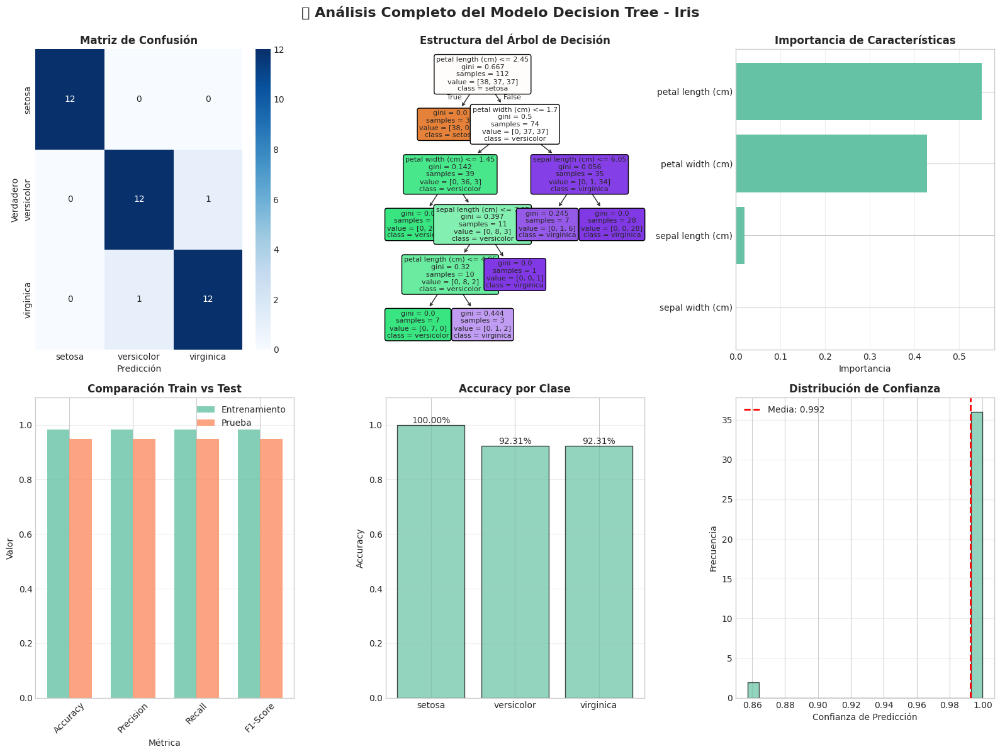

✅ Visualizaciones guardadas

📋 REPORTE DE CLASIFICACIÓN DETALLADO
              precision    recall  f1-score   support

      setosa     1.0000    1.0000    1.0000        12
  versicolor     0.9231    0.9231    0.9231        13
   virginica     0.9231    0.9231    0.9231        13

    accuracy                         0.9474        38
   macro avg     0.9487    0.9487    0.9487        38
weighted avg     0.9474    0.9474    0.9474        38

🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE
🆔 Run ID: b5fe4e0230d14d0588fb8e9bcd8b93ef
📊 Experimento: /Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
🎯 Accuracy (Test): 0.9474 (94.74%)
🌟 F1-Score (Test): 0.9474
📊 Cross-Val Accuracy: 0.9466 ± 0.0333
(3, 3, 2)
(3, 2, 2)

✅ Experimento finalizado correctamente


In [0]:
# ========================================
# ENTRENAMIENTO CON MLFLOW
# ========================================

# Activar autologging de MLflow
mlflow.sklearn.autolog()

# Desafío 1
hyperparams_matrix = {
    'max_depth': [3, 5, 10, None],
    'max_features' : [2, 3, 4, 'sqrt'],
    'min_samples_split' : [2, 5, 10]
}

best_cv_accuracy = 0
best_combo_for_accuracy = None

best_iris_recall_score = 0
best_combo = None

# itertools.product(*hyperparams_matrix.values()) — el * "desempaqueta" esas 3 listas como argumentos separados de product, que calcula el producto cartesiano: todas las formas de coger un elemento de la primera lista, uno de la segunda y uno de la tercera

keys = hyperparams_matrix.keys()
combinations = list(itertools.product(*hyperparams_matrix.values()))
fixed_params = {
    'random_state': 42
}
print(f"Se van a probar {len(combinations)} combinaciones")


for combo in combinations:
    
    params = dict(zip(keys, combo))
    params.update(fixed_params) 

    # Iniciar run con nombre descriptivo
    with mlflow.start_run(run_name="Decision Tree - Iris Classifier") as run:
        
        print("=" * 70)
        print("🚀 ENTRENAMIENTO DEL ÁRBOL DE DECISIÓN")
        print("=" * 70)
        
        
        print("\n⚙️  HIPERPARÁMETROS:")
        print(f"   - max_depth: {params['max_depth']}")
        print(f"   - max_features: {params['max_features']}")
        print(f"   - min_samples_split: {params['min_samples_split']}")
        # print(f"   - min_samples_leaf: {params['min_samples_leaf']}")
        
        # =====================================
        # 2. CREAR Y ENTRENAR EL MODELO
        # =====================================
        print("\n🌳 Creando Árbol de Decisión...")
        dt = DecisionTreeClassifier(**params
        )
        
        print("📚 Entrenando con", len(X_train), "muestras...")
        dt.fit(X_train, y_train)
        print("✅ Modelo entrenado exitosamente")
        
        # =====================================
        # 3. HACER PREDICCIONES
        # =====================================
        print("\n🔮 Realizando predicciones...")
        y_pred_train = dt.predict(X_train)
        y_pred_test = dt.predict(X_test)
        
        # Probabilidades para análisis adicional
        y_pred_proba_test = dt.predict_proba(X_test)
        
        print("✅ Predicciones completadas")
        
        # =====================================
        # 4. CALCULAR MÉTRICAS
        # =====================================
        print("\n📊 CALCULANDO MÉTRICAS DE CLASIFICACIÓN:")
        
        # Métricas de entrenamiento
        accuracy_train = accuracy_score(y_train, y_pred_train)
        precision_train = precision_score(y_train, y_pred_train, average='weighted')
        recall_train = recall_score(y_train, y_pred_train, average='weighted')
        f1_train = f1_score(y_train, y_pred_train, average='weighted')
        
        # Métricas de prueba
        accuracy_test = accuracy_score(y_test, y_pred_test)
        precision_test = precision_score(y_test, y_pred_test, average='weighted')
        recall_test = recall_score(y_test, y_pred_test, average='weighted')
        f1_test = f1_score(y_test, y_pred_test, average='weighted')
        
        # Cross-validation
        cv_scores = cross_val_score(dt, X_train, y_train, cv=5)
        cv_mean = cv_scores.mean()
        cv_std = cv_scores.std()
        
        print("\n   📚 ENTRENAMIENTO:")
        print(f"      - Accuracy:  {accuracy_train:.4f} ({accuracy_train*100:.2f}%)")
        print(f"      - Precision: {precision_train:.4f}")
        print(f"      - Recall:    {recall_train:.4f}")
        print(f"      - F1-Score:  {f1_train:.4f}")
        
        print("\n   🧪 PRUEBA:")
        print(f"      - Accuracy:  {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
        print(f"      - Precision: {precision_test:.4f}")
        print(f"      - Recall:    {recall_test:.4f}")
        print(f"      - F1-Score:  {f1_test:.4f}")
        
        print(f"\n   🔄 CROSS-VALIDATION (5-fold):")
        print(f"      - Mean Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
        
        # Calcular overfitting
        overfitting = accuracy_train - accuracy_test
        print(f"\n   ⚠️  Overfitting Score: {overfitting:.4f}")
        if overfitting < 0.05:
            print("      ✅ Excelente - Poco overfitting")
        elif overfitting < 0.10:
            print("      ⚡ Bueno - Overfitting moderado")
        else:
            print("      ⚠️  Cuidado - Posible overfitting")
        
        # =====================================
        # 5. REGISTRAR EN MLFLOW
        # =====================================
        print("\n📝 Registrando información en MLflow...")
        
        # Registrar hiperparámetros adicionales
        mlflow.log_param("max_depth", params['max_depth'])
        mlflow.log_param("max_features", params['max_features'])
        mlflow.log_param("min_samples_split", params['min_samples_split'])
        #mlflow.log_param("min_samples_leaf", params['min_samples_leaf'])
        mlflow.log_param("dataset", "Iris")
        mlflow.log_param("n_classes", len(dataset.target_names))
        
        # Registrar métricas
        mlflow.log_metric("train_accuracy", accuracy_train)
        mlflow.log_metric("test_accuracy", accuracy_test)
        mlflow.log_metric("train_precision", precision_train)
        mlflow.log_metric("test_precision", precision_test)
        mlflow.log_metric("train_recall", recall_train)
        mlflow.log_metric("test_recall", recall_test)
        mlflow.log_metric("train_f1", f1_train)
        mlflow.log_metric("test_f1", f1_test)
        mlflow.log_metric("cv_mean_accuracy", cv_mean)
        mlflow.log_metric("cv_std_accuracy", cv_std)
        mlflow.log_metric("overfitting_score", overfitting)
        
        # =====================================
        # 6. CREAR VISUALIZACIONES
        # =====================================
        print("\n📈 Generando visualizaciones...")
        
        # Figura con múltiples análisis
        fig = plt.figure(figsize=(16, 12))
        
        # 1. Matriz de Confusión
        ax1 = plt.subplot(2, 3, 1)
        cm = confusion_matrix(y_test, y_pred_test)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                    xticklabels=dataset.target_names,
                    yticklabels=dataset.target_names)
        ax1.set_title('Matriz de Confusión', fontweight='bold', fontsize=12)
        ax1.set_ylabel('Verdadero', fontsize=10)
        ax1.set_xlabel('Predicción', fontsize=10)
        
        # 2. Visualización del Árbol
        ax2 = plt.subplot(2, 3, 2)
        plot_tree(dt, 
                feature_names=dataset.feature_names,
                class_names=dataset.target_names,
                filled=True,
                rounded=True,
                ax=ax2,
                fontsize=8)
        ax2.set_title('Estructura del Árbol de Decisión', fontweight='bold', fontsize=12)
        
        # 3. Importancia de Características
        ax3 = plt.subplot(2, 3, 3)
        feature_importance = pd.DataFrame({
            'feature': dataset.feature_names,
            'importance': dt.feature_importances_
        }).sort_values('importance', ascending=True)
        ax3.barh(feature_importance['feature'], feature_importance['importance'])
        ax3.set_xlabel('Importancia', fontsize=10)
        ax3.set_title('Importancia de Características', fontweight='bold', fontsize=12)
        ax3.grid(True, alpha=0.3, axis='x')
        
        # 4. Comparación de Métricas
        ax4 = plt.subplot(2, 3, 4)
        metrics_comparison = pd.DataFrame({
            'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
            'Entrenamiento': [accuracy_train, precision_train, recall_train, f1_train],
            'Prueba': [accuracy_test, precision_test, recall_test, f1_test]
        })
        x = np.arange(len(metrics_comparison))
        width = 0.35
        ax4.bar(x - width/2, metrics_comparison['Entrenamiento'], width, label='Entrenamiento', alpha=0.8)
        ax4.bar(x + width/2, metrics_comparison['Prueba'], width, label='Prueba', alpha=0.8)
        ax4.set_xlabel('Métrica', fontsize=10)
        ax4.set_ylabel('Valor', fontsize=10)
        ax4.set_title('Comparación Train vs Test', fontweight='bold', fontsize=12)
        ax4.set_xticks(x)
        ax4.set_xticklabels(metrics_comparison['Métrica'], rotation=45)
        ax4.legend()
        ax4.grid(True, alpha=0.3, axis='y')
        ax4.set_ylim([0, 1.1])
        
        # 5. Predicciones por clase
        ax5 = plt.subplot(2, 3, 5)
        class_accuracy = []
        for i, class_name in enumerate(dataset.target_names):
            mask = y_test == i
            if mask.sum() > 0:
                acc = accuracy_score(y_test[mask], y_pred_test[mask])
                class_accuracy.append(acc)
            else:
                class_accuracy.append(0)
        
        bars = ax5.bar(dataset.target_names, class_accuracy, alpha=0.7, edgecolor='black')
        for bar, acc in zip(bars, class_accuracy):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{acc:.2%}', ha='center', va='bottom', fontsize=10)
        ax5.set_ylabel('Accuracy', fontsize=10)
        ax5.set_title('Accuracy por Clase', fontweight='bold', fontsize=12)
        ax5.set_ylim([0, 1.1])
        ax5.grid(True, alpha=0.3, axis='y')
        
        # 6. Distribución de confianza en predicciones
        ax6 = plt.subplot(2, 3, 6)
        max_probas = np.max(y_pred_proba_test, axis=1)
        ax6.hist(max_probas, bins=20, edgecolor='black', alpha=0.7)
        ax6.axvline(max_probas.mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'Media: {max_probas.mean():.3f}')
        ax6.set_xlabel('Confianza de Predicción', fontsize=10)
        ax6.set_ylabel('Frecuencia', fontsize=10)
        ax6.set_title('Distribución de Confianza', fontweight='bold', fontsize=12)
        ax6.legend()
        ax6.grid(True, alpha=0.3, axis='y')
        
        plt.suptitle('🌸 Análisis Completo del Modelo Decision Tree - Iris', 
                    fontsize=16, fontweight='bold', y=0.995)
        plt.tight_layout()
        
        # Guardar en MLflow
        mlflow.log_figure(fig, "model_analysis_complete.png")
        plt.show()
        
        print("✅ Visualizaciones guardadas")
        
        # =====================================
        # 7. REPORTE DE CLASIFICACIÓN
        # =====================================
        print("\n" + "=" * 70)
        print("📋 REPORTE DE CLASIFICACIÓN DETALLADO")
        print("=" * 70)
        print(classification_report(
            y_test, 
            y_pred_test, 
            target_names=dataset.target_names,
            digits=4
        ))
        
        # =====================================
        # 8. INFORMACIÓN FINAL
        # =====================================
        run_id = run.info.run_id
        
        print("=" * 70)
        print("🎉 ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
        print("=" * 70)
        print(f"🆔 Run ID: {run_id}")
        print(f"📊 Experimento: {experiment_name if email else 'No configurado'}")
        print(f"🎯 Accuracy (Test): {accuracy_test:.4f} ({accuracy_test*100:.2f}%)")
        print(f"🌟 F1-Score (Test): {f1_test:.4f}")
        print(f"📊 Cross-Val Accuracy: {cv_mean:.4f} ± {cv_std:.4f}")
        print("=" * 70)


        # Desafío 1
        if best_cv_accuracy < (cv_mean-cv_std):
            best_cv_accuracy = cv_mean-cv_std
            best_combo_for_accuracy = combo

        if best_iris_recall_score < recall_test : 
            best_iris_recall_score = recall_test
            best_combo = combo

        
        print(best_combo)
        print(best_combo_for_accuracy)



    mlflow.end_run()
    print("\n✅ Experimento finalizado correctamente")

In [0]:
print(experiment_name)
print(mlflow.get_experiment_by_name(experiment_name).experiment_id)
print(mlflow.search_runs(experiment_ids=[experiment.experiment_id]))
print(results_df.columns.tolist())

/Users/202637883@alu.comillas.edu/4-ejercicio-the-irish
2781564230117224


---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5682584358606524>, line 3
      1 print(experiment_name)
      2 print(mlflow.get_experiment_by_name(experiment_name).experiment_id)
----> 3 print(mlflow.search_runs(experiment_ids=[experiment.experiment_id]))
      4 print(results_df.columns.tolist())

NameError: name 'experiment' is not defined

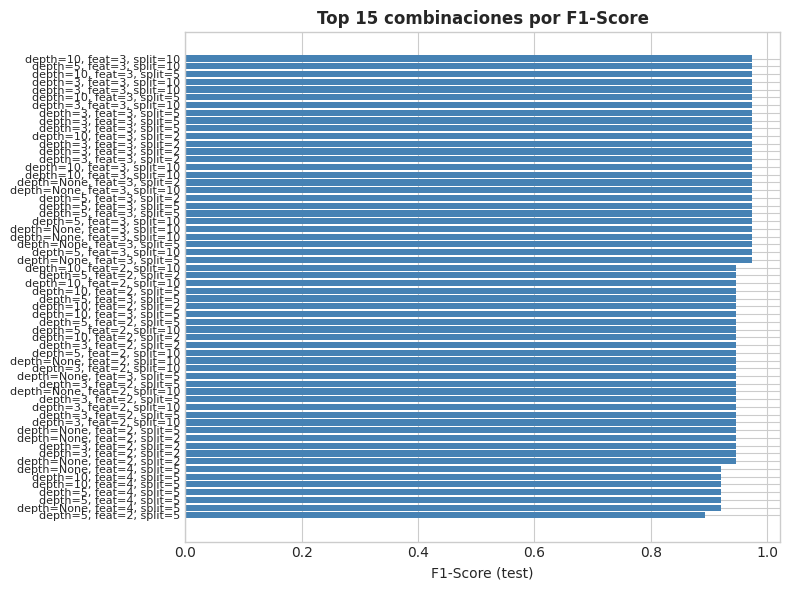

In [0]:

experiment = mlflow.get_experiment_by_name(experiment_name) 
results_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

top_n = results_df.sort_values('metrics.test_f1', ascending=False).head(60)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top_n)), top_n['metrics.test_f1'], color='steelblue')
ax.set_yticks(range(len(top_n)))
ax.set_yticklabels([f"depth={row['params.max_depth']}, feat={row['params.max_features']}, split={row['params.min_samples_split']}"
                     for _, row in top_n.iterrows()], fontsize=8)
ax.invert_yaxis()  
ax.set_xlabel('F1-Score (test)')
ax.set_title('Top 15 combinaciones por F1-Score', fontweight='bold')
plt.tight_layout()
plt.show()

## 🎯 ¡Excelente Trabajo! Ejercicio Completado

### ✅ Lo que has Logrado

1. ✅ **Explorado el dataset Iris** con análisis visual completo
2. ✅ **Entrenado un Árbol de Decisión** para clasificación multiclase
3. ✅ **Evaluado con múltiples métricas** (Accuracy, Precision, Recall, F1)
4. ✅ **Implementado Cross-Validation** para validación robusta
5. ✅ **Registrado todo en MLflow** de forma profesional
6. ✅ **Creado visualizaciones avanzadas** (matriz de confusión, árbol, etc.)

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**Ventajas:**
- ✅ Fácil de interpretar y visualizar
- ✅ No requiere normalización de datos
- ✅ Maneja datos numéricos y categóricos
- ✅ Captura relaciones no lineales

**Desventajas:**
- ⚠️ Propenso a overfitting
- ⚠️ Inestable ante pequeños cambios
- ⚠️ Puede crear sesgos con clases desbalanceadas

### 📊 Matriz de Confusión

```
                Predicción
              Setosa  Versi  Virgin
Real Setosa     [TP]   [FP]   [FP]
     Versi      [FN]   [TP]   [FP]
     Virgin     [FN]   [FN]   [TP]
```

- **TP (True Positive)**: Predicción correcta
- **FP (False Positive)**: Error tipo I
- **FN (False Negative)**: Error tipo II

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**Pregunta**: ¿Qué combinación da el mejor balance entre accuracy y overfitting? 
max_depth = [3]
max_features = [3]
min_samples_split = [2]

Desafío 3: **Pregunta**: ¿Cuál funciona mejor para Iris? ¿Por qué?
max_depth = [3]
max_features = [2]
min_samples_split = [2]
[Porque quizás el resto o bien tienen mucho overfitting (max_depth alto)
 o bien underfitting (min_samples_split alto)]
Desafío 4:
Analiza las predicciones incorrectas:
- ¿Qué flores se confunden más?: Versicolor y vergicolor. 
- ¿Por qué características similares causan errores?: Porque si dicha característica es similar para dos o más clases diferentes, se dice que dicha característica tiene ``poco poder discriminativo'', es decir, para el modelo no es útil ya que lo que se busca son características que tengan valores diferentes para diferentes clases objetivo.
- ¿Cómo mejorarías el modelo? O bien aplicando PCA para reducir dimensionalidad y ver si en otras combinaciones lineales hay más separación o 
LDA (Linear Discriminant Analysis), que busca explícitamente la proyección que maximiza la separación entre clases.

---

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo:

```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 10, None],
    'max_features': [2, 3, 4],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Completa el código...
```

---

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara:
- Random Forest
- SVM (Support Vector Machine)
- KNN (K-Nearest Neighbors)
- Logistic Regression

**Pregunta**: ¿Cuál funciona mejor para Iris? ¿Por qué?

---

### 🎯 Desafío 4: Análisis de Errores



---

### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa solo 2 características y visualiza:

```python
from sklearn.decomposition import PCA

# Reducir a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Entrenar y visualizar límites de decisión
```

---

## 💡 Tips para Mejorar

### 🎨 Mejora la Organización en MLflow

```python
# Agregar tags descriptivos
mlflow.set_tag("tipo_modelo", "decision_tree")
mlflow.set_tag("dataset", "iris")
mlflow.set_tag("objetivo", "clasificacion_multiclase")
mlflow.set_tag("version", "1.0")
mlflow.set_tag("autor", "tu_nombre")

# Agregar notas
mlflow.set_tag("notas", "Primer experimento baseline")
```

### 📊 Experimenta con Visualizaciones

```python
# Límites de decisión en 2D
from matplotlib.colors import ListedColormap
# ... código para visualizar límites ...

# Curvas de aprendizaje
from sklearn.model_selection import learning_curve
# ... código para curvas de aprendizaje ...
```

### 🔄 Validación Cruzada Estratificada

```python
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt, X, y, cv=skf)
```

---

## 🎓 Recursos Adicionales

### 📖 Documentación
- [Scikit-learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)
- [Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)
- [MLflow Tracking](https://mlflow.org/docs/latest/tracking.html)

### 🎥 Tutoriales
- Interpretación de matrices de confusión
- Árboles de decisión explicados visualmente
- Optimización de hiperparámetros

### 📊 Datasets Similares
- **Wine Quality**: Clasificación de vinos
- **Digits**: Reconocimiento de dígitos escritos
- **Breast Cancer**: Diagnóstico médico

---

## 🌟 Próximos Pasos

1. **Completa los desafíos** propuestos
2. **Compara tus resultados** en MLflow UI
3. **Documenta tus hallazgos** con tags y notas
4. **Experimenta con otros datasets** de clasificación
5. **Aprende sobre ensembles** (Random Forest, Gradient Boosting)

---

## 🎉 ¡Felicitaciones!

Has completado con éxito el ejercicio de clasificación de Iris con MLflow. Ahora tienes las habilidades para:

- ✅ Trabajar con problemas de clasificación multiclase
- ✅ Evaluar modelos con métricas apropiadas
- ✅ Interpretar matrices de confusión
- ✅ Visualizar resultados de clasificación
- ✅ Documentar experimentos profesionalmente

**¡Sigue practicando y mejorando tus habilidades en Machine Learning! 🚀🌸**

In [0]:
# 🎨 CÓDIGO DE EJEMPLO PARA LOS DESAFÍOS
# Descomenta y experimenta con diferentes configuraciones

# ========================================
# DESAFÍO 1: Optimización Manual
# ========================================
# configuraciones = [
#     {'max_depth': 3, 'max_features': 2},
#     {'max_depth': 5, 'max_features': 3},
#     {'max_depth': 10, 'max_features': 4},
#     {'max_depth': None, 'max_features': 'sqrt'},
# ]
# 
# mlflow.sklearn.autolog()
# for i, config in enumerate(configuraciones):
#     with mlflow.start_run(run_name=f"DT Config {i+1}"):
#         dt = DecisionTreeClassifier(**config, random_state=42)
#         dt.fit(X_train, y_train)
#         accuracy = accuracy_score(y_test, dt.predict(X_test))
#         print(f"Config {i+1}: {config} -> Accuracy: {accuracy:.4f}")

# ========================================
# DESAFÍO 2: Grid Search
# ========================================
# from sklearn.model_selection import GridSearchCV
# 
# param_grid = {
#     'max_depth': [3, 5, 10, None],
#     'max_features': [2, 3, 4],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# 
# mlflow.sklearn.autolog()
# with mlflow.start_run(run_name="Grid Search - Decision Tree"):
#     grid_search = GridSearchCV(
#         DecisionTreeClassifier(random_state=42),
#         param_grid,
#         cv=5,
#         scoring='accuracy',
#         verbose=1,
#         n_jobs=-1
#     )
#     grid_search.fit(X_train, y_train)
#     
#     print(f"Mejores parámetros: {grid_search.best_params_}")
#     print(f"Mejor accuracy (CV): {grid_search.best_score_:.4f}")
#     print(f"Accuracy en test: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")

# ========================================
# DESAFÍO 3: Comparación de Modelos
# ========================================
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.linear_model import LogisticRegression
# 
# modelos = {
#     'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
#     'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
#     'SVM': SVC(kernel='rbf', random_state=42),
#     'KNN': KNeighborsClassifier(n_neighbors=5),
#     'Logistic Regression': LogisticRegression(max_iter=200, random_state=42)
# }
# 
# resultados = []
# mlflow.sklearn.autolog()
# 
# for nombre, modelo in modelos.items():
#     with mlflow.start_run(run_name=f"{nombre} - Iris"):
#         modelo.fit(X_train, y_train)
#         y_pred = modelo.predict(X_test)
#         
#         acc = accuracy_score(y_test, y_pred)
#         f1 = f1_score(y_test, y_pred, average='weighted')
#         
#         resultados.append({
#             'Modelo': nombre,
#             'Accuracy': acc,
#             'F1-Score': f1
#         })
#         print(f"{nombre}: Accuracy={acc:.4f}, F1={f1:.4f}")
# 
# # Visualizar comparación
# df_resultados = pd.DataFrame(resultados).sort_values('Accuracy', ascending=False)
# print("\n📊 Ranking de Modelos:")
# print(df_resultados.to_string(index=False))

# ========================================
# DESAFÍO 4: Análisis de Errores
# ========================================
# # Encontrar predicciones incorrectas
# incorrect_indices = np.where(y_pred_test != y_test)[0]
# 
# print(f"Total de errores: {len(incorrect_indices)}")
# print("\nAnálisis de errores:")
# for idx in incorrect_indices:
#     true_class = dataset.target_names[y_test[idx]]
#     pred_class = dataset.target_names[y_pred_test[idx]]
#     print(f"  Muestra {idx}: Real={true_class}, Predicción={pred_class}")
#     print(f"    Características: {X_test[idx]}")

# ========================================
# DESAFÍO 5: PCA y Visualización 2D
# ========================================
# from sklearn.decomposition import PCA
# 
# # Reducir a 2 dimensiones
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X)
# X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
#     X_pca, y, test_size=0.25, random_state=42, stratify=y
# )
# 
# # Entrenar modelo con datos reducidos
# dt_pca = DecisionTreeClassifier(max_depth=5, random_state=42)
# dt_pca.fit(X_train_pca, y_train_pca)
# 
# # Visualizar límites de decisión
# from matplotlib.colors import ListedColormap
# 
# h = 0.02  # step size
# x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
# y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
# xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
#                      np.arange(y_min, y_max, h))
# 
# Z = dt_pca.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)
# 
# plt.figure(figsize=(10, 8))
# plt.contourf(xx, yy, Z, alpha=0.4, cmap=plt.cm.RdYlBu)
# scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, 
#                       edgecolors='black', s=80, cmap=plt.cm.RdYlBu)
# plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} varianza)')
# plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} varianza)')
# plt.title('Límites de Decisión con PCA (2D)')
# plt.colorbar(scatter)
# plt.show()
# 
# print(f"Accuracy con PCA: {accuracy_score(y_test_pca, dt_pca.predict(X_test_pca)):.4f}")

print("💡 Descomenta y ejecuta el código del desafío que quieras explorar")